## test.csv 구조 확인 

### 데이터 로드

In [1]:
import pandas as pd

df_test = pd.read_csv("C:\\Users\\jd091\\data\\test.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df_test.head())

       시    구    동            시군구     번지   본번   부번     아파트명   전용면적(㎡)    계약년월  \
0  서울특별시  강남구  개포동  서울특별시 강남구 개포동  658-1  658  1.0   개포6차우성   79.9700  202307   
1  서울특별시  강남구  개포동  서울특별시 강남구 개포동  651-1  651  1.0  개포더샵트리에  108.2017  202308   
2  서울특별시  강남구  개포동  서울특별시 강남구 개포동    652  652  0.0   개포우성3차  161.0000  202307   
3  서울특별시  강남구  개포동  서울특별시 강남구 개포동    652  652  0.0   개포우성3차  133.4600  202308   
4  서울특별시  강남구  개포동  서울특별시 강남구 개포동    652  652  0.0   개포우성3차  104.4300  202308   

   ...      건축면적   주차대수  기타/의무/임대/임의=1/2/3/4                  단지승인일  사용허가여부  \
0  ...   4858.00  262.0                   임의  2022-11-17 13:00:29.0       Y   
1  ...   2724.46  305.0                   의무  2022-02-23 13:01:10.0       Y   
2  ...  61064.24  419.0                   의무  1984-12-22 00:00:00.0       Y   
3  ...  61064.24  419.0                   의무  1984-12-22 00:00:00.0       Y   
4  ...  61064.24  419.0                   의무  1984-12-22 00:00:00.0       Y   

   관리비 업로드         좌표X        좌표Y     

In [2]:
df_test['구'].nunique()

25

In [4]:
import pandas as pd

df_test_before = pd.read_csv("C:\\Users\\jd091\\test.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df_test_before.head())

             시군구     번지     본번   부번     아파트명   전용면적(㎡)    계약년월  계약일   층  건축년도  \
0  서울특별시 강남구 개포동  658-1  658.0  1.0   개포6차우성   79.9700  202307   26   5  1987   
1  서울특별시 강남구 개포동  651-1  651.0  1.0  개포더샵트리에  108.2017  202308   15  10  2021   
2  서울특별시 강남구 개포동    652  652.0  0.0   개포우성3차  161.0000  202307   28  15  1984   
3  서울특별시 강남구 개포동    652  652.0  0.0   개포우성3차  133.4600  202308   10  14  1984   
4  서울특별시 강남구 개포동    652  652.0  0.0   개포우성3차  104.4300  202308   18   6  1984   

   ... 청소비관리형태      건축면적   주차대수 기타/의무/임대/임의=1/2/3/4                  단지승인일  \
0  ...      직영   4858.00  262.0                  임의  2022-11-17 13:00:29.0   
1  ...      위탁   2724.46  305.0                  의무  2022-02-23 13:01:10.0   
2  ...      위탁  61064.24  419.0                  의무  1984-12-22 00:00:00.0   
3  ...      위탁  61064.24  419.0                  의무  1984-12-22 00:00:00.0   
4  ...      위탁  61064.24  419.0                  의무  1984-12-22 00:00:00.0   

  사용허가여부 관리비 업로드         좌표X        좌표Y     

In [5]:
df_test_before.columns

Index(['시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월', '계약일', '층', '건축년도',
       '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지', 'k-단지분류(아파트,주상복합등등)',
       'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)', 'k-관리방식', 'k-복도유형',
       'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)', 'k-시행사', 'k-사용검사일-사용승인일',
       'k-연면적', 'k-주거전용면적', 'k-관리비부과면적', 'k-전용면적별세대현황(60㎡이하)',
       'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하', 'k-135㎡초과', 'k-홈페이지',
       'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태', '세대전기계약방법', '청소비관리형태',
       '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일', '사용허가여부', '관리비 업로드',
       '좌표X', '좌표Y', '단지신청일'],
      dtype='object')

In [2]:
import numpy as np

# NaN을 0으로 대체 (API 검색 실패 시 추적용)
df_test['본번'] = df_test['본번'].fillna(0).astype(int)
# 1. 도로명 주소 생성 (부번 제거 + 본번 정수 처리)
df_test.loc[:, '도로명주소'] = (
    df_test['시'].fillna('') + ' ' +
    df_test['구'].fillna('') + ' ' +
    df_test['도로명'].fillna('') + ' ' 
).str.strip()

# 2. 지번 주소 생성 (도로명 없는 경우만)
roadname_mask = (
    df_test['도로명'].isna() | 
    (df_test['도로명'] == '')
)

df_test.loc[:, '지번주소'] = np.where(
    roadname_mask,
    df_test['시군구'].fillna('') + ' ' +
    df_test['번지'].astype(str) + ' ',   # 번지도 정수 처리
    ''
)

In [ ]:
'''
이미 완료한 코드라 더이상 실행 안함 
df_test[['시', '구', '동']] = df_test['시군구'].str.split(' ', expand=True)

cols = ['시', '구', '동'] + [col for col in df_test.columns if col not in ['시', '구', '동']]
df_test = df_test[cols]'''

In [128]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9272 entries, 0 to 9271
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   시                       9272 non-null   object 
 1   구                       9272 non-null   object 
 2   동                       9272 non-null   object 
 3   시군구                     9272 non-null   object 
 4   번지                      9270 non-null   object 
 5   본번                      9272 non-null   float64
 6   부번                      9272 non-null   float64
 7   아파트명                    9262 non-null   object 
 8   전용면적(㎡)                 9272 non-null   float64
 9   계약년월                    9272 non-null   int64  
 10  계약일                     9272 non-null   int64  
 11  층                       9272 non-null   int64  
 12  건축년도                    9272 non-null   int64  
 13  도로명                     9272 non-null   object 
 14  해제사유발생일                 212 non-null    

### 결측치 채우기

#### 의미없는 데이터 nan 처리


In [129]:
# 위 처럼 아무 의미도 갖지 않는 칼럼은 결측치와 같은 역할을 하므로, np.nan으로 채워 결측치로 인식
import numpy as np
df_test['등기신청일자'] = df_test['등기신청일자'].replace(' ', np.nan)
df_test['거래유형'] = df_test['거래유형'].replace('-', np.nan)
df_test['중개사소재지'] = df_test['중개사소재지'].replace('-', np.nan)

#### 결측치 갯수 확인

In [204]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_test.isnull().sum()[df_test.isnull().sum() > 0]

번지                           2
아파트명                        10
해제사유발생일                   9060
등기신청일자                    7364
중개사소재지                     432
k-단지분류(아파트,주상복합등등)        6582
k-전화번호                    6576
k-팩스번호                    6606
단지소개기존clob                8718
k-세대타입(분양형태)              6562
k-관리방식                    6562
k-복도유형                    6564
k-난방방식                    6562
k-전체동수                    6577
k-전체세대수                   6562
k-건설사(시공사)                2096
k-시행사                     2096
k-사용검사일-사용승인일             6563
k-연면적                     6562
k-주거전용면적                  6562
k-관리비부과면적                 6562
k-전용면적별세대현황(60㎡이하)        6562
k-전용면적별세대현황(60㎡~85㎡이하)    6562
k-85㎡~135㎡이하              6562
k-135㎡초과                  9270
k-홈페이지                    7876
k-등록일자                    8554
k-수정일자                    6562
고용보험관리번호                  7453
경비비관리형태                   6573
세대전기계약방법                  6642
청소비관리형태                   6573
건축면적    

#### 좌표 x,y 채워넣기

##### 좌표 결측치인 missing_coords_df2 생성 

In [132]:
# 좌표X 또는 좌표Y가 NaN인 행만 추출
missing_coords_df2 = df_test[df_test['좌표X'].isna()]

In [133]:
missing_coords_df2.columns

Index(['시', '구', '동', '시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월',
       '계약일', '층', '건축년도', '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지',
       'k-단지분류(아파트,주상복합등등)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)',
       'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)',
       'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적', 'k-관리비부과면적',
       'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하',
       'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태',
       '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일',
       '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일'],
      dtype='object')

In [134]:
missing_coords_df2

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,청소비관리형태,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일
113,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189.0,0.0,개포자이프레지던스,59.98,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185.0,0.0,개포주공7단지,73.26,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185.0,0.0,개포주공7단지,73.26,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185.0,0.0,개포주공7단지,53.46,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185.0,0.0,개포주공7단지,73.26,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9253,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450.0,0.0,한신,59.76,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9254,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450.0,0.0,한신,59.76,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9255,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450.0,0.0,한신,50.37,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9256,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450.0,0.0,한신,59.76,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### 카카오 api 사용-> 검색을 할 주소 생성

In [ ]:
import numpy as np

# NaN을 0으로 대체 (API 검색 실패 시 추적용)
missing_coords_df2['본번'] = missing_coords_df2['본번'].fillna(0).astype(int)
# 1. 도로명 주소 생성 (부번 제거 + 본번 정수 처리)
missing_coords_df2.loc[:, '도로명주소'] = (
    missing_coords_df2['시'].fillna('') + ' ' +
    missing_coords_df2['구'].fillna('') + ' ' +
    missing_coords_df2['도로명'].fillna('') + ' ' 
).str.strip()

# 2. 지번 주소 생성 (도로명 없는 경우만)
roadname_mask = (
    missing_coords_df2['도로명'].isna() | 
    (missing_coords_df2['도로명'] == '')
)

missing_coords_df2.loc[:, '지번주소'] = np.where(
    roadname_mask,
    missing_coords_df2['시군구'].fillna('') + ' ' +
    missing_coords_df2['번지'].astype(str) + ' ',   # 번지도 정수 처리
    ''
)

In [ ]:
missing_coords_df2

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,도로명주소,지번주소
113,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189,0.0,개포자이프레지던스,59.98,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 삼성로 14,
114,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185,0.0,개포주공7단지,73.26,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 개포로 516,
115,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185,0.0,개포주공7단지,73.26,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 개포로 516,
116,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185,0.0,개포주공7단지,53.46,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 개포로 516,
117,서울특별시,강남구,개포동,서울특별시 강남구 개포동,185,185,0.0,개포주공7단지,73.26,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 개포로 516,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9253,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450,0.0,한신,59.76,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 중랑구 동일로 752,
9254,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450,0.0,한신,59.76,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 중랑구 동일로 752,
9255,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450,0.0,한신,50.37,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 중랑구 동일로 752,
9256,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,450,450,0.0,한신,59.76,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 중랑구 동일로 752,


In [ ]:
missing_coords_df2.columns 

Index(['시', '구', '동', '시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월',
       '계약일', '층', '건축년도', '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지',
       'k-단지분류(아파트,주상복합등등)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)',
       'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)',
       'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적', 'k-관리비부과면적',
       'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하',
       'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태',
       '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일',
       '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일', '도로명주소', '지번주소'],
      dtype='object')

#### k시공사 명 채워넣기

##### 1. 결측치 갯수 확인 

In [2]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_test.isnull().sum()[df_test.isnull().sum() > 0]

번지                           2
아파트명                        10
해제사유발생일                   9060
등기신청일자                    7364
중개사소재지                     432
k-단지분류(아파트,주상복합등등)        6582
k-전화번호                    6576
k-팩스번호                    6606
단지소개기존clob                8718
k-세대타입(분양형태)              6562
k-관리방식                    6562
k-복도유형                    6564
k-난방방식                    6562
k-전체동수                    6577
k-전체세대수                   6562
k-건설사(시공사)                1677
k-시행사                     1677
k-사용검사일-사용승인일             6563
k-연면적                     6562
k-주거전용면적                  6562
k-관리비부과면적                 6562
k-전용면적별세대현황(60㎡이하)        6562
k-전용면적별세대현황(60㎡~85㎡이하)    6562
k-85㎡~135㎡이하              6562
k-135㎡초과                  9270
k-홈페이지                    7876
k-등록일자                    8554
k-수정일자                    6562
고용보험관리번호                  7453
경비비관리형태                   6573
세대전기계약방법                  6642
청소비관리형태                   6573
건축면적    

##### 2. 건설사 브랜드명 정의 

In [172]:
# construction_data 예시 (여러 건설사, 여러 브랜드)
construction_data = {
    "삼성물산": {
        '초고급': ['트라팰리스','타워팰리스'],
        "하이엔드": ["원베일리"],
        "일반": ["래미안","삼성","푸른마을"]
    },
    "현대건설": {
        '초고급': ['하이페리온',"슈퍼빌"],
        "하이엔드": ["디에이치"],
        "일반": ["힐스테이트",'현대']
    },
    "HDC현대": {
        "일반": ["아이파크","중계그린","I-PARK","I'PARK","시영",'IPARK']
    },
    "대우건설": {
        "하이엔드": ["써밋"],
        "일반": ["푸르지오","대우"]
    },
    "대림산업": {
        "하이엔드": ["아크로"],
        "일반": ["이편한세상",'e편한세상','대림','e-편한세상','이-편한세상']
    },
    "GS건설": {
        "초고급": ["메세나"],
        "일반": ["자이","LG","럭키"]
    },
    "포스코": {
        "하이엔드": ["오티에르"],
        "일반": ['더샵']
    },
    "롯데": {
        "초고급":['롯데캐슬골드',"나인원"],
        "하이엔드": ["르엘"],
        "일반": ["롯데캐슬"]
    },
    "SK건설": {
        "일반": ["SK뷰",'에스케이뷰',"에스케이","SK"]
    },
    "한화건설": {
        "초고급":['갤러리아'],
        "하이엔드": ["오벨리스크","포레나"],
        "일반": ["꿈에그린","한화"]
    },
    "두산에너빌리티": {
        "하이엔드": ["트리마제","더제니스"],
        "일반": ["두산위브","두산","동현"]
    },
    "호반건설": {
        "일반": ["베르디움","리젠시빌",'호반써밋',"스카이써밋"]
    },
    "태영건설": {
        "일반": ["데시앙","태영"]
    },
    "상지카일룸": {
        "일반": ["상지리츠빌"]
    },
    "금호건설": {
        "최고급": ["한남더힐"],
        "일반": ["벽산","금호"]
    }
    ,
    "동부건설": {
        "일반": ["센트레빌"]
    },
    "신동아건설": {
        "일반": ["신동아",'파밀리에']
    },
    "쌍용건설": {
        "일반": ["쌍용"]
    },
    "LH": {
        "일반": ["LH",'엘에이치','주공',"휴먼시아","천년나무","뜨란채"]
    },
    "한신공영": {
        "일반": ["한신","한진","신반포"]
    },
    "우성건설": {
        "일반": ["우성"]
    },
    "중앙건설": {
        "일반": ["중앙","하이츠"]
    },
    "동아건설": {
        "일반": ["동아"]
    },
    "삼익건설": {
        "일반": ["삼익"]
    },
    "극동건설": {
        "일반": ["극동"]
    },
    "라이프주택개발": {
        "일반": ["미성","장미","라이프","진주","미주"]
    },
    "성원건설": {
        "일반": ["성원"]
    },
    "SM경남기업": {
        "일반": ["경남",'SM',"삼환","우방"]
    },
    "청구": {
        "일반": ["청구"]
    },
    "건영": {
        "일반": ["LIG","건영"]
    }
    ,
    "새롬성원산업": {
        "일반": ["청솔"]
    }
    ,
    "코오롱건설": {
        "일반": ["코오롱"]
    }
    ,
    "동양건설": {
        "일반": ["파라곤"]
    },
    "월드건설": {
        "일반": ["메르디앙"]
    },
    "풍림산업": {
        "일반": ["풍림"]
    },
    "금강주택": {
        "일반": ["금강"]
    }
    ,
    "효성중공업": {
        "일반": ["효성",'해링턴']
    },
    "BS한양": {
        "일반": ["한양",'수자인']
    },
    "삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설": {
        "일반": ["목동"]
    },
    "한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업": {
        "일반": ["올림픽선수기자촌"]
    },
    "서희건설": {
        "일반": ["서희",'스타힐스']
    },
    "계룡건설": {
        "일반": ['계룡',"리슈빌"]
    },
    "제일건설": {
        "일반": ['풍경채',"제일"]
    },
    "중흥토건": {
        "일반": ['중흥',"S-클래스"]
    },
    "대방건설": {
        "일반": ["대방"]
    },
    "대우건설,대림산업,삼성물산,두산건설,라온건설": {
        "일반": ["길음뉴타운"]
    },
    "보람종합건설": {
        "일반": ["보람"]
    },
    "삼호건설": {
        "일반": ["삼호"]
    }
}

##### 3. 값 채워넣기 

In [173]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '남산타운', 'k-건설사(시공사)'] = "현대건설,동아건설,SK건설"

In [174]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '태강', 'k-건설사(시공사)'] = "삼환건설,현대건설"

In [175]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '파크리오', 'k-건설사(시공사)'] = "현대건설,삼성물산,대림산업,두산건설,쌍용건설"

In [176]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '관악드림', 'k-건설사(시공사)'] = "삼성물산,동아건설산업"

In [177]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '삼환', 'k-건설사(시공사)'] = "현대건설,SM경남기업"

In [178]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '트리지움', 'k-건설사(시공사)'] = "GS건설,현대건설,현대산업개발"

In [179]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_test.loc[df_test['아파트명'] == '리센츠', 'k-건설사(시공사)'] = "대우건설,삼성물산,대림산업"

In [180]:
#1차로 빈 건설사 값 채우기 
#df_train에 반영
for company, categories in construction_data.items():
    all_brands = []
    for brand_list in categories.values():
        all_brands.extend(brand_list)
    pattern = '|'.join(map(str, all_brands))
    
    # 3가지 조건 결합
    condition = (
        df_test['아파트명'].str.contains(pattern, na=False) &  # 브랜드명 포함
        df_test['k-건설사(시공사)'].isna() &                   # 시공사 NaN
        ~df_test['아파트명'].str.contains(',', na=False)       # 콤마 없어야 함
    )
    
    df_test.loc[condition, 'k-건설사(시공사)'] = company

In [181]:
# construction_data를 기반으로 브랜드명 -> 건설사 매핑 딕셔너리 생성
brand_to_company = {}
for company, categories in construction_data.items():
    for brand_list in categories.values():
        for brand in brand_list:
            brand_to_company[brand] = company

# 아파트명에 콤마가 있고, k-건설사가 NaN인 행 필터링
condition = (
    df_test['아파트명'].str.contains(',', na=False) & 
    df_test['k-건설사(시공사)'].isna()
)

# 각 행 처리
for idx in df_test[condition].index:
    # 아파트명을 콤마로 분리
    brands = [x.strip() for x in df_test.loc[idx, '아파트명'].split(',')]
    
    # 브랜드별 건설사 찾기 (중복 제거)
    companies = set()
    for brand in brands:
        if brand in brand_to_company:
            companies.add(brand_to_company[brand])
    
    # 건설사가 존재할 경우 콤마로 연결해 할당
    if companies:
        df_test.loc[idx, 'k-건설사(시공사)'] = ','.join(sorted(companies))

In [182]:
# k-건설사(시공사)는 값이 있고, k-시행사는 NaN인 경우에 한해 k-시행사에 k-건설사(시공사) 값을 채워넣기
condition = df_test['k-건설사(시공사)'].notna() & df_test['k-시행사'].isna()
df_test.loc[condition, 'k-시행사'] = df_test.loc[condition, 'k-건설사(시공사)']

In [183]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_test.isnull().sum()[df_test.isnull().sum() > 0]

번지                           2
아파트명                        10
해제사유발생일                   9060
등기신청일자                    7364
중개사소재지                     432
k-단지분류(아파트,주상복합등등)        6582
k-전화번호                    6576
k-팩스번호                    6606
단지소개기존clob                8718
k-세대타입(분양형태)              6562
k-관리방식                    6562
k-복도유형                    6564
k-난방방식                    6562
k-전체동수                    6577
k-전체세대수                   6562
k-건설사(시공사)                1677
k-시행사                     1677
k-사용검사일-사용승인일             6563
k-연면적                     6562
k-주거전용면적                  6562
k-관리비부과면적                 6562
k-전용면적별세대현황(60㎡이하)        6562
k-전용면적별세대현황(60㎡~85㎡이하)    6562
k-85㎡~135㎡이하              6562
k-135㎡초과                  9270
k-홈페이지                    7876
k-등록일자                    8554
k-수정일자                    6562
고용보험관리번호                  7453
경비비관리형태                   6573
세대전기계약방법                  6642
청소비관리형태                   6573
건축면적    

In [184]:
a=df_test[df_test['k-건설사(시공사)'].isna()]
a

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,도로명주소
165,서울특별시,강남구,논현동,서울특별시 강남구 논현동,196,196,0.0,거평프리젠,30.215,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,127.027637,37.506370,NaN,서울특별시 강남구 강남대로112길 41
171,서울특별시,강남구,논현동,서울특별시 강남구 논현동,267-23,267,23.0,마블하우스,142.480,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,127.042351,37.512383,NaN,서울특별시 강남구 봉은사로51길 36
186,서울특별시,강남구,대치동,서울특별시 강남구 대치동,891-28,891,28.0,대치동우정에쉐르1,59.960,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,127.054209,37.504544,NaN,서울특별시 강남구 삼성로85길 38
191,서울특별시,강남구,대치동,서울특별시 강남구 대치동,914-8,914,8.0,대치타워,85.810,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,127.058002,37.501727,NaN,서울특별시 강남구 삼성로71길 11-8
208,서울특별시,강남구,대치동,서울특별시 강남구 대치동,506,506,0.0,선경1차,136.680,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,127.062565,37.492127,NaN,서울특별시 강남구 삼성로 151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9238,서울특별시,중랑구,신내동,서울특별시 중랑구 신내동,654,654,0.0,진로,134.370,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,126.808434,37.577043,NaN,서울특별시 중랑구 신내로17길 41
9239,서울특별시,중랑구,신내동,서울특별시 중랑구 신내동,654,654,0.0,진로,101.860,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,126.808434,37.577043,NaN,서울특별시 중랑구 신내로17길 41
9240,서울특별시,중랑구,신내동,서울특별시 중랑구 신내동,654,654,0.0,진로,101.860,202309,...,NaN,NaN,NaN,NaN,NaN,NaN,126.808434,37.577043,NaN,서울특별시 중랑구 신내로17길 41
9247,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,208-4,208,4.0,범양프레체,17.940,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,127.075881,37.594486,NaN,서울특별시 중랑구 중랑천로14길 58


In [185]:
# 건설사가 NaN인 행의 아파트명 빈도 계산 및 정렬
result_df = (
    df_test[df_test['k-건설사(시공사)'].isna()]  # 1. 건설사가 NaN인 행 필터링
    ['아파트명']                                    # 2. 아파트명 컬럼 선택
    .value_counts()                                # 3. 빈도 계산
    .reset_index()                                 # 4. 인덱스 재설정(DataFrame 변환)
    .rename(columns={'count': '빈도'})             # 5. 컬럼명 변경
    .sort_values('빈도', ascending=False)          # 6. 빈도 기준 내림차순 정렬
)

# 결과 출력 (상위 10개)
result_df.head(40)

,아파트명,빈도
0,아츠스테이수유점,60
1,고덕그라시움,49
2,고덕아르테온,26
3,까치마을,22
4,강변,21
5,신트리1,18
6,텐즈힐,16
7,위례24단지,14
8,한마을,14
9,청화1,13


#### k 시공사명 재 정의


##### 1. 삼성 

In [257]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('삼성', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False) 

)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '삼성물산'

In [258]:
df_test[df_test['k-건설사(시공사)'].str.contains("삼성", na=False)]['k-건설사(시공사)'].unique()

array(['삼성물산', '삼성물산,동아건설산업', '삼성물산,두산건설', '삼성물산, 대림산업', '삼성물산, 현대산업개발',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '현대건설,삼성물산,현대산업개발', '삼성물산,한화건설',
       '대림,삼성,현대,현산', '현대건설,삼성물산,대림산업,두산건설,쌍용건설', '대우건설,삼성물산,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

##### 2. 현대 

In [259]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('현대건설', na=False) & 
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False) & #콤마는 안들어감
    ~df_test['k-건설사(시공사)'].str.contains('현대산업개발', na=False)& # 
    ~df_test['k-건설사(시공사)'].str.contains('HDC현대', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [260]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('현대산업개발', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False) & #콤마는 안들어감
    ~df_test['k-건설사(시공사)'].str.contains('현대건설', na=False)# 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = 'HDC현대'

In [261]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('현대종합건설', na=False)  #
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [262]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('현대엔지니어링', na=False)  #
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [263]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('현대힐스테이트', na=False)  #
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [264]:
df_test[df_test['k-건설사(시공사)'].str.contains("현대", na=False)]['k-건설사(시공사)'].unique()

array(['현대건설', '현대,쌍용,GS', 'HDC현대', '현대건설,SM경남기업', '현대,대림',
       '현대건설,현대산업개발,한진중공업', '풍림산업,현대건설', '우성건설,현대건설', '삼환건설,현대건설',
       '현대BS&C', '삼성물산, 현대산업개발', '포스코,SK,현대', '현대건설,삼성물산,현대산업개발',
       '태영건설, 현대산업개발', '대림,삼성,현대,현산', '현대건설,삼성물산,대림산업,두산건설,쌍용건설',
       'GS건설,현대건설,현대산업개발', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설',
       '현대건설,동아건설,SK건설'], dtype=object)

##### 3. GS 

In [265]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('GS', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

In [266]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('LG', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

In [267]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('럭키', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

In [268]:
df_test[df_test['k-건설사(시공사)'].str.contains("럭키", na=False)]['k-건설사(시공사)'].unique()

array([], dtype=object)

##### 4. 포스코

In [269]:
df_test[df_test['k-건설사(시공사)'].str.contains("포스코", na=False)]['k-건설사(시공사)'].unique()

array(['포스코', '포스코,SK,현대'], dtype=object)

In [270]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('포스코', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '포스코'

In [271]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('포스코, 포스코A&C', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '포스코'

In [272]:
df_test[df_test['k-건설사(시공사)'].str.contains("포스코", na=False)]['k-건설사(시공사)'].unique()

array(['포스코', '포스코,SK,현대'], dtype=object)

##### 5. 롯데건설 

In [273]:
df_test[df_test['k-건설사(시공사)'].str.contains("롯데", na=False)]['k-건설사(시공사)'].unique()

array(['롯데건설', '롯데건설,우성건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '대림산업, 롯데건설'], dtype=object)

In [274]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('롯데', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '롯데건설'

In [275]:
df_test[df_test['k-건설사(시공사)'].str.contains("롯데", na=False)]['k-건설사(시공사)'].unique()

array(['롯데건설', '롯데건설,우성건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '대림산업, 롯데건설'], dtype=object)

##### 6. 호반건설


In [276]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('호반건설', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '호반건설'

In [277]:
df_test[df_test['k-건설사(시공사)'].str.contains("호반", na=False)]['k-건설사(시공사)'].unique()

array(['호반건설'], dtype=object)

##### 7. 대림산업

In [278]:
df_test[df_test['k-건설사(시공사)'].str.contains("대림", na=False)]['k-건설사(시공사)'].unique()

array(['대림산업', '대우건설,대림산업,태영건설', '현대,대림', '삼성물산, 대림산업',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '대림,삼성,현대,현산',
       '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업', '현대건설,삼성물산,대림산업,두산건설,쌍용건설',
       '대우건설,삼성물산,대림산업', '대림산업, 롯데건설'], dtype=object)

In [279]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('대림', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '대림산업'

In [280]:
df_test[df_test['k-건설사(시공사)'].str.contains("대림", na=False)]['k-건설사(시공사)'].unique()

array(['대림산업', '대우건설,대림산업,태영건설', '현대,대림', '삼성물산, 대림산업',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '대림,삼성,현대,현산',
       '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업', '현대건설,삼성물산,대림산업,두산건설,쌍용건설',
       '대우건설,삼성물산,대림산업', '대림산업, 롯데건설'], dtype=object)

##### 8. SK

In [281]:
df_test[df_test['k-건설사(시공사)'].str.contains("SK", na=False)]['k-건설사(시공사)'].unique()

array(['SK건설', '포스코,SK,현대', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설',
       '현대건설,동아건설,SK건설'], dtype=object)

In [282]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('에스케이건설', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = 'SK건설'

In [283]:
df_test[df_test['k-건설사(시공사)'].str.contains("에스케이", na=False)]['k-건설사(시공사)'].unique()

array([], dtype=object)

##### 9. 대우

In [284]:
df_test[df_test['k-건설사(시공사)'].str.contains("대우", na=False)]['k-건설사(시공사)'].unique()

array(['대우건설', '대우건설,대림산업,태영건설', '이수건설,대우엔지니어링', '유원, 선경, 대우건설', '남광, 대우',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '대우건설,삼성물산,대림산업', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'],
      dtype=object)

In [285]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('대우', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '대우건설'

In [286]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('대우푸르지오', na=False) & #삼성이 들어감
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '대우건설'

In [287]:
df_test[df_test['k-건설사(시공사)'].str.contains("대우", na=False)]['k-건설사(시공사)'].unique()

array(['대우건설', '대우건설,대림산업,태영건설', '이수건설,대우엔지니어링', '유원, 선경, 대우건설', '남광, 대우',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '대우건설,삼성물산,대림산업', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'],
      dtype=object)

##### 10. 한화건설

In [288]:
df_test[df_test['k-건설사(시공사)'].str.contains("한화", na=False)]['k-건설사(시공사)'].unique()

array(['한화건설', '삼성물산,한화건설'], dtype=object)

In [289]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('한화건설', na=False) &
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '한화건설'

In [290]:
df_test[df_test['k-건설사(시공사)'].str.contains("한화", na=False)]['k-건설사(시공사)'].unique()

array(['한화건설', '삼성물산,한화건설'], dtype=object)

##### 11. 두산 

In [291]:
df_test[df_test['k-건설사(시공사)'].str.contains("두산", na=False)]['k-건설사(시공사)'].unique()

array(['두산건설', '두산, 이수건설', '삼성물산,두산건설', '대우건설,대림산업,삼성물산,두산건설,라온건설',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설'], dtype=object)

In [292]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('두산', na=False) & 
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '두산건설'

In [293]:
df_test[df_test['k-건설사(시공사)'].str.contains("두산", na=False)]['k-건설사(시공사)'].unique()

array(['두산건설', '두산, 이수건설', '삼성물산,두산건설', '대우건설,대림산업,삼성물산,두산건설,라온건설',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설'], dtype=object)

##### 12. 이상치  

In [294]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('박연정', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

##### 13. 코오롱

In [295]:
df_test[df_test['k-건설사(시공사)'].str.contains("코오롱", na=False)]['k-건설사(시공사)'].unique()

array(['코오롱건설'], dtype=object)

In [296]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('코오롱', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '코오롱건설'

In [297]:
df_test[df_test['k-건설사(시공사)'].str.contains("코오롱", na=False)]['k-건설사(시공사)'].unique()

array(['코오롱건설'], dtype=object)

##### 14. 계룡건설

In [298]:
df_test[df_test['k-건설사(시공사)'].str.contains("계룡", na=False)]['k-건설사(시공사)'].unique()

array(['계룡건설'], dtype=object)

In [299]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('계룡', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '계룡건설'

##### 15. 금호건설


In [300]:
df_test[df_test['k-건설사(시공사)'].str.contains("금호", na=False)]['k-건설사(시공사)'].unique()

array(['금호건설'], dtype=object)

In [301]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('금호', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '금호건설'

##### 16. 우성건설


In [302]:
df_test[df_test['k-건설사(시공사)'].str.contains("우성", na=False)]['k-건설사(시공사)'].unique()

array(['우성건설', '우성건설,현대건설', '롯데건설,우성건설'], dtype=object)

In [303]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('우성', na=False)&
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '우성건설'

In [304]:
df_test[df_test['k-건설사(시공사)'].str.contains("우성", na=False)]['k-건설사(시공사)'].unique()

array(['우성건설', '우성건설,현대건설', '롯데건설,우성건설'], dtype=object)

##### 17. 극동건설

In [305]:
df_test[df_test['k-건설사(시공사)'].str.contains("극동", na=False)]['k-건설사(시공사)'].unique()


array(['극동건설', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

In [306]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('극동', na=False)&
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '극동건설'

In [307]:
df_test[df_test['k-건설사(시공사)'].str.contains("극동", na=False)]['k-건설사(시공사)'].unique()

array(['극동건설', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

##### 18. 동아건설

In [ ]:
df_test[df_test['k-건설사(시공사)'].str.contains("동아", na=False)]['k-건설사(시공사)'].unique()

array(['신동아건설', '신동아', '신동아건설(주)', '동아건설', '신동아 건설(주)', '삼성물산,동아건설산업',
       '동아건설산업(주)', '(주)동아건설산업', '현대건설,동아건설,SK건설'], dtype=object)

In [ ]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('동아', na=False)&
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '동아건설'

In [ ]:
df_test[df_test['k-건설사(시공사)'].str.contains("동아", na=False)]['k-건설사(시공사)'].unique()

array(['동아건설', '삼성물산,동아건설산업', '현대건설,동아건설,SK건설'], dtype=object)

##### 19. 유원건설

In [42]:
df_test[df_test['k-건설사(시공사)'].str.contains("유원", na=False)]['k-건설사(시공사)'].unique()

array(['유원, 선경, 대우건설', '유원건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

In [43]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('유원', na=False)&
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '유원건설'

In [44]:
df_test[df_test['k-건설사(시공사)'].str.contains("유원", na=False)]['k-건설사(시공사)'].unique()

array(['유원, 선경, 대우건설', '유원건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

##### 20. 라이프주택개발

In [45]:
df_test[df_test['k-건설사(시공사)'].str.contains("라이프", na=False)]['k-건설사(시공사)'].unique()


array(['(주)건영,삼익주택,라이프주택', '라이프주택개발', '라이프건설', '라이프주택',
       '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업'], dtype=object)

In [46]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_test['k-건설사(시공사)'].str.contains('라이프', na=False)&
    ~df_test['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_test.loc[condition, 'k-건설사(시공사)'] = '라이프주택개발'

In [47]:
df_test[df_test['k-건설사(시공사)'].str.contains("라이프", na=False)]['k-건설사(시공사)'].unique()

array(['(주)건영,삼익주택,라이프주택', '라이프주택개발', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업'],
      dtype=object)

## train 데이터 구조 확인

### 데이터 로드

In [2]:
import pandas as pd

df_train = pd.read_csv("C:\\Users\\jd091\\data\\train.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df_train.head())

C:\Users\jd091\AppData\Local\Temp\ipykernel_28696\2580574317.py:3: DtypeWarning: Columns (16,17,19,20,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("C:\\Users\\jd091\\data\\train.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'


       시    구    동            시군구     번지   본번   부번    아파트명  전용면적(㎡)    계약년월  \
0  서울특별시  강남구  개포동  서울특별시 강남구 개포동  658-1  658  1.0  개포6차우성    79.97  201712   
1  서울특별시  강남구  개포동  서울특별시 강남구 개포동  658-1  658  1.0  개포6차우성    79.97  201712   
2  서울특별시  강남구  개포동  서울특별시 강남구 개포동  658-1  658  1.0  개포6차우성    54.98  201712   
3  서울특별시  강남구  개포동  서울특별시 강남구 개포동  658-1  658  1.0  개포6차우성    79.97  201801   
4  서울특별시  강남구  개포동  서울특별시 강남구 개포동  658-1  658  1.0  개포6차우성    79.97  201801   

   ...                  단지승인일  사용허가여부  관리비 업로드        좌표X        좌표Y  \
0  ...  2022-11-17 13:00:29.0       Y        N  127.05721  37.476763   
1  ...  2022-11-17 13:00:29.0       Y        N  127.05721  37.476763   
2  ...  2022-11-17 13:00:29.0       Y        N  127.05721  37.476763   
3  ...  2022-11-17 13:00:29.0       Y        N  127.05721  37.476763   
4  ...  2022-11-17 13:00:29.0       Y        N  127.05721  37.476763   

                   단지신청일  target            도로명주소 지번주소 k-건설사(시공사)_cleaned  
0  2022-11-17 10

In [3]:
import pandas as pd

df_train_before = pd.read_csv("C:\\Users\\jd091\\train.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df_train_before.head())

C:\Users\jd091\AppData\Local\Temp\ipykernel_28696\1217340473.py:3: DtypeWarning: Columns (16,17,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train_before = pd.read_csv("C:\\Users\\jd091\\train.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'


             시군구     번지     본번   부번    아파트명  전용면적(㎡)    계약년월  계약일  층  건축년도  \
0  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201712    8  3  1987   
1  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201712   22  4  1987   
2  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    54.98  201712   28  5  1987   
3  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201801    3  4  1987   
4  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201801    8  2  1987   

   ...    건축면적   주차대수 기타/의무/임대/임의=1/2/3/4                  단지승인일 사용허가여부  \
0  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
1  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
2  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
3  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
4  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   

  관리비 업로드        좌표X        좌표Y                  단지신청일  target  
0       N  127.

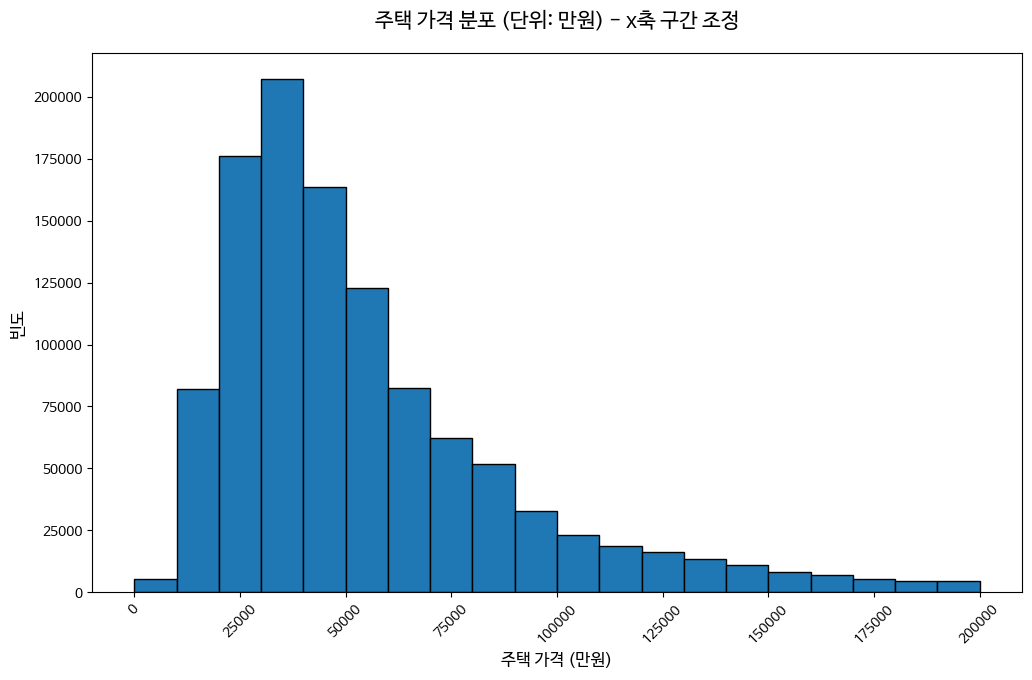

In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (Colab/Jupyter 환경)
plt.rcParams['font.family'] = 'NanumBarunGothic'  # 나눔바른고딕 설치 필요
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 표시
plt.figure(figsize=(12, 7))

# 0부터 200,000만원(2억원)까지 1만 단위로 구간 설정
max_bin = 200000
bins = range(0, max_bin + 10000, 10000)  # 1만 단위(1천만원) 구간

plt.hist(df_train['target'], bins=bins, color='#1f77b4', edgecolor='black')

plt.title('주택 가격 분포 (단위: 만원) - x축 구간 조정', fontsize=15, pad=20)
plt.xlabel('주택 가격 (만원)', fontsize=12)
plt.ylabel('빈도', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(False)
plt.show()

In [93]:
df_train_sorted = df_train.sort_values(by='건축년도', ascending=True)

In [94]:
import numpy as np

# NaN을 0으로 대체 (API 검색 실패 시 추적용)
df_train['본번'] = df_train['본번'].fillna(0).astype(int)
# 1. 도로명 주소 생성 (부번 제거 + 본번 정수 처리)
df_train.loc[:, '도로명주소'] = (
    df_train['시'].fillna('') + ' ' +
    df_train['구'].fillna('') + ' ' +
    df_train['도로명'].fillna('') + ' ' 
).str.strip()

# 2. 지번 주소 생성 (도로명 없는 경우만)
roadname_mask = (
    df_train['도로명'].isna() | 
    (df_train['도로명'] == '')
)

df_train.loc[:, '지번주소'] = np.where(
    roadname_mask,
    df_train['시군구'].fillna('') + ' ' +
    df_train['번지'].astype(str) + ' ',   # 번지도 정수 처리
    ''
)

In [95]:
'''df_train[['시', '구', '동']] = df_train['시군구'].str.split(' ', expand=True)

cols = ['시', '구', '동'] + [col for col in df_train.columns if col not in ['시', '구', '동']]
df_train = df_train[cols]'''

"df_train[['시', '구', '동']] = df_train['시군구'].str.split(' ', expand=True)\n\ncols = ['시', '구', '동'] + [col for col in df_train.columns if col not in ['시', '구', '동']]\ndf_train = df_train[cols]"

In [96]:
df_train.head()

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소,지번주소
0,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201712,...,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,124000,서울특별시 강남구 언주로 3,
1,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201712,...,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,123500,서울특별시 강남구 언주로 3,
2,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,54.98,201712,...,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,91500,서울특별시 강남구 언주로 3,
3,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201801,...,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,130000,서울특별시 강남구 언주로 3,
4,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201801,...,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,117000,서울특별시 강남구 언주로 3,


### 결측치 채우기

#### 결측치 갯수 확인

In [232]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_train.isnull().sum()[df_train.isnull().sum() > 0]

번지                            225
부번                             75
아파트명                         2126
해제사유발생일                   1112839
등기신청일자                    1103907
거래유형                      1086451
중개사소재지                    1089581
k-단지분류(아파트,주상복합등등)         870691
k-전화번호                     870274
k-팩스번호                     872742
단지소개기존clob                1050240
k-세대타입(분양형태)               869563
k-관리방식                     869563
k-복도유형                     869890
k-난방방식                     869563
k-전체동수                     870630
k-전체세대수                    869563
k-건설사(시공사)                 304748
k-시행사                      304748
k-사용검사일-사용승인일              869696
k-연면적                      869563
k-주거전용면적                   869608
k-관리비부과면적                  869563
k-전용면적별세대현황(60㎡이하)         869608
k-전용면적별세대현황(60㎡~85㎡이하)     869608
k-85㎡~135㎡이하               869608
k-135㎡초과                  1118495
k-홈페이지                    1005647
k-등록일자                    1107832
k-수정일자        

#### 결측치 차이 시각화

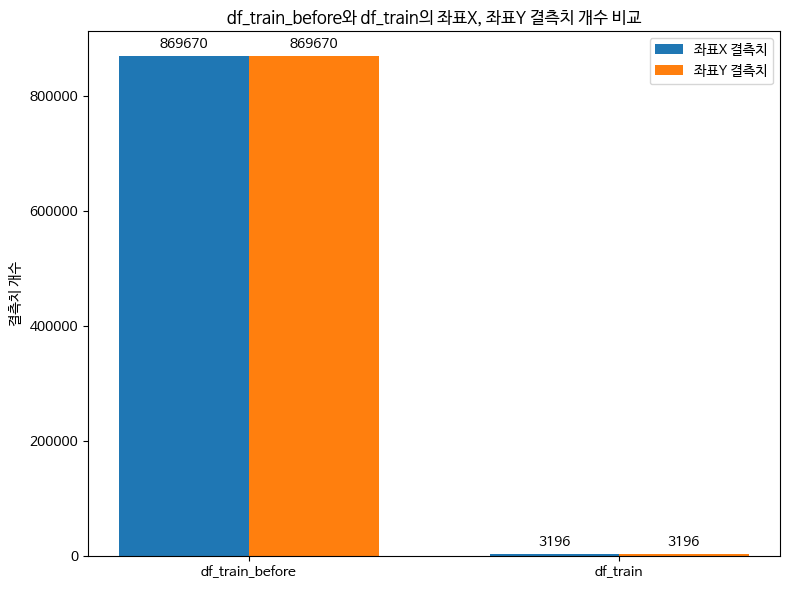

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

#한글 폰트 설정 
fe = fm.FontEntry(
    fname=r'C:\\Windows\\Fonts\\NanumBarunGothic.ttf',
    name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumBarunGothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False        # 마이너스 깨짐 방지

import matplotlib.pyplot as plt
import numpy as np

# 각 데이터프레임의 결측치 개수 계산
missing_before_x = df_train_before['좌표X'].isna().sum()
missing_before_y = df_train_before['좌표Y'].isna().sum()
missing_xdf_x = missing_x_df['좌표X'].isna().sum()
missing_xdf_y = missing_x_df['좌표Y'].isna().sum()
missing_train_x = df_train['좌표X'].isna().sum()
missing_train_y = df_train['좌표Y'].isna().sum()

labels = ['df_train_before', 'missing_x_df', 'df_train']
missing_x = [missing_before_x, missing_xdf_x, missing_train_x]
missing_y = [missing_before_y, missing_xdf_y, missing_train_y]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, missing_x, width, label='좌표X 결측치')
rects2 = ax.bar(x + width/2, missing_y, width, label='좌표Y 결측치')

ax.set_ylabel('결측치 개수')
ax.set_title('세 데이터프레임의 좌표X, 좌표Y 결측치 개수 비교')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# 막대 위에 결측치 개수 표시
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 좌표x,y 채워넣기

##### 좌표 결측치인 missing_coords_df 생성 

In [8]:
# 좌표X 또는 좌표Y가 NaN인 행만 추출
missing_coords_df = df_train_before[df_train_before['좌표X'].isna()]

In [9]:
missing_coords_df.columns

Index(['시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월', '계약일', '층', '건축년도',
       '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지', 'k-단지분류(아파트,주상복합등등)',
       'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)', 'k-관리방식', 'k-복도유형',
       'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)', 'k-시행사', 'k-사용검사일-사용승인일',
       'k-연면적', 'k-주거전용면적', 'k-관리비부과면적', 'k-전용면적별세대현황(60㎡이하)',
       'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하', 'k-135㎡초과', 'k-홈페이지',
       'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태', '세대전기계약방법', '청소비관리형태',
       '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일', '사용허가여부', '관리비 업로드',
       '좌표X', '좌표Y', '단지신청일', 'target'],
      dtype='object')

In [10]:
missing_coords_df

,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,계약일,층,건축년도,...,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target
975,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201801,25,1,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134000
976,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201801,25,4,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158000
977,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201801,25,1,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155000
978,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,42.55,201801,26,4,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132000
979,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201802,10,1,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118203,서울특별시 중랑구 중화동,274-77,274.0,77.0,한영,70.96,200709,6,4,2003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17000
1118204,서울특별시 중랑구 중화동,11,11.0,0.0,현대휴앤미,100.17,200704,23,2,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21000
1118205,서울특별시 중랑구 중화동,11,11.0,0.0,현대휴앤미,95.94,200704,26,3,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27000
1118206,서울특별시 중랑구 중화동,11,11.0,0.0,현대휴앤미,100.20,200705,19,6,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24200


##### 카카오 api 사용-> 검색을 할 주소 생성

In [ ]:
import numpy as np

# NaN을 0으로 대체 (API 검색 실패 시 추적용)
missing_coords_df['본번'] = missing_coords_df['본번'].fillna(0).astype(int)
# 1. 도로명 주소 생성 (부번 제거 + 본번 정수 처리)
missing_coords_df.loc[:, '도로명주소'] = (
    missing_coords_df['시'].fillna('') + ' ' +
    missing_coords_df['구'].fillna('') + ' ' +
    missing_coords_df['도로명'].fillna('') + ' ' 
).str.strip()

# 2. 지번 주소 생성 (도로명 없는 경우만)
roadname_mask = (
    missing_coords_df['도로명'].isna() | 
    (missing_coords_df['도로명'] == '')
)

missing_coords_df.loc[:, '지번주소'] = np.where(
    roadname_mask,
    missing_coords_df['시군구'].fillna('') + ' ' +
    missing_coords_df['번지'].astype(str) + ' ',   # 번지도 정수 처리
    ''
)

C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2656560466.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_coords_df['본번'] = missing_coords_df['본번'].fillna(0).astype(int)
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2656560466.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_coords_df.loc[:, '지번주소'] = np.where(


In [ ]:
missing_coords_df

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소,지번주소
975,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189,0.0,개포주공4단지,50.39,201801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134000,서울특별시 강남구 삼성로 14,
976,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189,0.0,개포주공4단지,50.39,201801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158000,서울특별시 강남구 삼성로 14,
977,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189,0.0,개포주공4단지,50.39,201801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155000,서울특별시 강남구 삼성로 14,
978,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189,0.0,개포주공4단지,42.55,201801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132000,서울특별시 강남구 삼성로 14,
979,서울특별시,강남구,개포동,서울특별시 강남구 개포동,189,189,0.0,개포주공4단지,50.39,201802,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154000,서울특별시 강남구 삼성로 14,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118203,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,274-77,274,77.0,한영,70.96,200709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17000,서울특별시 중랑구 동일로144길 74,
1118204,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,11,11,0.0,현대휴앤미,100.17,200704,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21000,서울특별시 중랑구 봉화산로27가길 23,
1118205,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,11,11,0.0,현대휴앤미,95.94,200704,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27000,서울특별시 중랑구 봉화산로27가길 23,
1118206,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,11,11,0.0,현대휴앤미,100.20,200705,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24200,서울특별시 중랑구 봉화산로27가길 23,


In [ ]:
missing_coords_df.columns

Index(['시', '구', '동', '시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월',
       '계약일', '층', '건축년도', '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지',
       'k-단지분류(아파트,주상복합등등)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)',
       'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)',
       'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적', 'k-관리비부과면적',
       'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하',
       'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태',
       '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일',
       '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일', 'target', '도로명주소', '지번주소'],
      dtype='object')

#### k시공사 명 채워넣기

건설사들이 가진 아파트 브랜드 명 검색해서 k 시공사 채워넣기

##### 1. 결측치 갯수 확인

In [97]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_train.isnull().sum()[df_train.isnull().sum() > 0]

번지                            225
부번                             75
아파트명                         2126
해제사유발생일                   1112839
등기신청일자                    1103907
거래유형                      1086451
중개사소재지                    1089581
k-단지분류(아파트,주상복합등등)         870691
k-전화번호                     870274
k-팩스번호                     872742
단지소개기존clob                1050240
k-세대타입(분양형태)               869563
k-관리방식                     869563
k-복도유형                     869890
k-난방방식                     869563
k-전체동수                     870630
k-전체세대수                    869563
k-건설사(시공사)                 304748
k-시행사                      304748
k-사용검사일-사용승인일              869696
k-연면적                      869563
k-주거전용면적                   869608
k-관리비부과면적                  869563
k-전용면적별세대현황(60㎡이하)         869608
k-전용면적별세대현황(60㎡~85㎡이하)     869608
k-85㎡~135㎡이하               869608
k-135㎡초과                  1118495
k-홈페이지                    1005647
k-등록일자                    1107832
k-수정일자        

##### 2. 건설사 브랜드 명 정의 

In [98]:
# construction_data 예시 (여러 건설사, 여러 브랜드)
construction_data = {
    "삼성물산": {
        '초고급': ['트라팰리스','타워팰리스'],
        "하이엔드": ["원베일리"],
        "일반": ["래미안","삼성","푸른마을"]
    },
    "현대건설": {
        '초고급': ['하이페리온',"슈퍼빌"],
        "하이엔드": ["디에이치"],
        "일반": ["힐스테이트",'현대']
    },
    "HDC현대": {
        "일반": ["아이파크","중계그린","I-PARK","I'PARK","시영",'IPARK']
    },
    "대우건설": {
        "하이엔드": ["써밋"],
        "일반": ["푸르지오","대우"]
    },
    "대림산업": {
        "하이엔드": ["아크로"],
        "일반": ["이편한세상",'e편한세상','대림','e-편한세상','이-편한세상']
    },
    "GS건설": {
        "초고급": ["메세나"],
        "일반": ["자이","LG","럭키"]
    },
    "포스코": {
        "하이엔드": ["오티에르"],
        "일반": ['더샵']
    },
    "롯데": {
        "초고급":['롯데캐슬골드',"나인원"],
        "하이엔드": ["르엘"],
        "일반": ["롯데캐슬"]
    },
    "SK건설": {
        "일반": ["SK뷰",'에스케이뷰',"에스케이","SK"]
    },
    "한화건설": {
        "초고급":['갤러리아'],
        "하이엔드": ["오벨리스크","포레나"],
        "일반": ["꿈에그린","한화"]
    },
    "두산에너빌리티": {
        "하이엔드": ["트리마제","더제니스"],
        "일반": ["두산위브","두산","동현"]
    },
    "호반건설": {
        "일반": ["베르디움","리젠시빌",'호반써밋',"스카이써밋"]
    },
    "태영건설": {
        "일반": ["데시앙","태영"]
    },
    "상지카일룸": {
        "일반": ["상지리츠빌"]
    },
    "금호건설": {
        "최고급": ["한남더힐"],
        "일반": ["벽산","금호"]
    }
    ,
    "동부건설": {
        "일반": ["센트레빌"]
    },
    "신동아건설": {
        "일반": ["신동아",'파밀리에']
    },
    "쌍용건설": {
        "일반": ["쌍용"]
    },
    "LH": {
        "일반": ["LH",'엘에이치','주공',"휴먼시아","천년나무","뜨란채"]
    },
    "한신공영": {
        "일반": ["한신","한진","신반포"]
    },
    "우성건설": {
        "일반": ["우성"]
    },
    "중앙건설": {
        "일반": ["중앙","하이츠"]
    },
    "동아건설": {
        "일반": ["동아"]
    },
    "삼익건설": {
        "일반": ["삼익"]
    },
    "극동건설": {
        "일반": ["극동"]
    },
    "라이프주택개발": {
        "일반": ["미성","장미","라이프","진주","미주"]
    },
    "성원건설": {
        "일반": ["성원"]
    },
    "SM경남기업": {
        "일반": ["경남",'SM',"삼환","우방"]
    },
    "청구": {
        "일반": ["청구"]
    },
    "건영": {
        "일반": ["LIG","건영"]
    }
    ,
    "새롬성원산업": {
        "일반": ["청솔"]
    }
    ,
    "코오롱건설": {
        "일반": ["코오롱"]
    }
    ,
    "동양건설": {
        "일반": ["파라곤"]
    },
    "월드건설": {
        "일반": ["메르디앙"]
    },
    "풍림산업": {
        "일반": ["풍림"]
    },
    "금강주택": {
        "일반": ["금강"]
    }
    ,
    "효성중공업": {
        "일반": ["효성",'해링턴']
    },
    "BS한양": {
        "일반": ["한양",'수자인']
    },
    "삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설": {
        "일반": ["목동"]
    },
    "한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업": {
        "일반": ["올림픽선수기자촌"]
    },
    "서희건설": {
        "일반": ["서희",'스타힐스']
    },
    "계룡건설": {
        "일반": ['계룡',"리슈빌"]
    },
    "제일건설": {
        "일반": ['풍경채',"제일"]
    },
    "중흥토건": {
        "일반": ['중흥',"S-클래스"]
    },
    "대방건설": {
        "일반": ["대방"]
    },
    "대우건설,대림산업,삼성물산,두산건설,라온건설": {
        "일반": ["길음뉴타운"]
    },
    "보람종합건설": {
        "일반": ["보람"]
    },
    "삼호건설": {
        "일반": ["삼호"]
    }


}

##### 3. 값 채워넣기

In [99]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '남산타운', 'k-건설사(시공사)'] = "현대건설,동아건설,SK건설"

In [100]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '태강', 'k-건설사(시공사)'] = "삼환건설,현대건설"

In [101]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '파크리오', 'k-건설사(시공사)'] = "현대건설,삼성물산,대림산업,두산건설,쌍용건설"

In [102]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '관악드림', 'k-건설사(시공사)'] = "삼성물산,동아건설산업"

In [103]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '삼환', 'k-건설사(시공사)'] = "현대건설,SM경남기업"

In [104]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '트리지움', 'k-건설사(시공사)'] = "GS건설,현대건설,현대산업개발"

In [105]:
# '아파트명'이 '파크리오'인 모든 행의 'k-건설사(시공사)' 값을 지정된 값으로 일괄 입력
df_train.loc[df_train['아파트명'] == '리센츠', 'k-건설사(시공사)'] = "대우건설,삼성물산,대림산업"

In [106]:
#1차로 빈 건설사 값 채우기 
#df_train에 반영
for company, categories in construction_data.items():
    all_brands = []
    for brand_list in categories.values():
        all_brands.extend(brand_list)
    pattern = '|'.join(map(str, all_brands))
    
    # 3가지 조건 결합
    condition = (
        df_train['아파트명'].str.contains(pattern, na=False) &  # 브랜드명 포함
        df_train['k-건설사(시공사)'].isna() &                   # 시공사 NaN
        ~df_train['아파트명'].str.contains(',', na=False)       # 콤마 없어야 함
    )
    
    df_train.loc[condition, 'k-건설사(시공사)'] = company

In [107]:
# construction_data를 기반으로 브랜드명 -> 건설사 매핑 딕셔너리 생성
brand_to_company = {}
for company, categories in construction_data.items():
    for brand_list in categories.values():
        for brand in brand_list:
            brand_to_company[brand] = company

# 아파트명에 콤마가 있고, k-건설사가 NaN인 행 필터링
condition = (
    df_train['아파트명'].str.contains(',', na=False) & 
    df_train['k-건설사(시공사)'].isna()
)

# 각 행 처리
for idx in df_train[condition].index:
    # 아파트명을 콤마로 분리
    brands = [x.strip() for x in df_train.loc[idx, '아파트명'].split(',')]
    
    # 브랜드별 건설사 찾기 (중복 제거)
    companies = set()
    for brand in brands:
        if brand in brand_to_company:
            companies.add(brand_to_company[brand])
    
    # 건설사가 존재할 경우 콤마로 연결해 할당
    if companies:
        df_train.loc[idx, 'k-건설사(시공사)'] = ','.join(sorted(companies))


In [108]:
# k-건설사(시공사)는 값이 있고, k-시행사는 NaN인 경우에 한해 k-시행사에 k-건설사(시공사) 값을 채워넣기
condition = df_train['k-건설사(시공사)'].notna() & df_train['k-시행사'].isna()
df_train.loc[condition, 'k-시행사'] = df_train.loc[condition, 'k-건설사(시공사)']

In [109]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_train.isnull().sum()[df_train.isnull().sum() > 0]

번지                            225
부번                             75
아파트명                         2126
해제사유발생일                   1112839
등기신청일자                    1103907
거래유형                      1086451
중개사소재지                    1089581
k-단지분류(아파트,주상복합등등)         870691
k-전화번호                     870274
k-팩스번호                     872742
단지소개기존clob                1050240
k-세대타입(분양형태)               869563
k-관리방식                     869563
k-복도유형                     869890
k-난방방식                     869563
k-전체동수                     870630
k-전체세대수                    869563
k-건설사(시공사)                 253847
k-시행사                      253847
k-사용검사일-사용승인일              869696
k-연면적                      869563
k-주거전용면적                   869608
k-관리비부과면적                  869563
k-전용면적별세대현황(60㎡이하)         869608
k-전용면적별세대현황(60㎡~85㎡이하)     869608
k-85㎡~135㎡이하               869608
k-135㎡초과                  1118495
k-홈페이지                    1005647
k-등록일자                    1107832
k-수정일자        

In [110]:
a=df_train[df_train['k-건설사(시공사)'].isna()]
a

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소,지번주소
1064,서울특별시,강남구,개포동,서울특별시 강남구 개포동,1204-5,1204,5.0,리치타운,68.64,201801,...,NaN,NaN,NaN,NaN,127.050374,37.477350,NaN,46400,서울특별시 강남구 개포로28길 28,
1118,서울특별시,강남구,개포동,서울특별시 강남구 개포동,1164-13,1164,13.0,새롬,59.96,201806,...,NaN,NaN,NaN,NaN,127.053096,37.473283,NaN,46500,서울특별시 강남구 논현로2길 36,
1119,서울특별시,강남구,개포동,서울특별시 강남구 개포동,1164-13,1164,13.0,새롬,59.96,201808,...,NaN,NaN,NaN,NaN,127.053096,37.473283,NaN,49500,서울특별시 강남구 논현로2길 36,
1224,서울특별시,강남구,개포동,서울특별시 강남구 개포동,1164-7,1164,7.0,아람손프라자/비바빌,59.96,201803,...,NaN,NaN,NaN,NaN,127.052232,37.472715,NaN,35000,서울특별시 강남구 논현로2길 22,
1225,서울특별시,강남구,개포동,서울특별시 강남구 개포동,166-4,166,4.0,에버그린,83.58,201801,...,NaN,NaN,NaN,NaN,127.061290,37.482914,NaN,65000,서울특별시 강남구 선릉로8길 5,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118203,서울특별시,중랑구,중화동,서울특별시 중랑구 중화동,274-77,274,77.0,한영,70.96,200709,...,NaN,NaN,NaN,NaN,127.038031,37.656751,NaN,17000,서울특별시 중랑구 동일로144길 74,
1118502,서울특별시,구로구,개봉동,서울특별시 구로구 개봉동,175-8,175,8.0,청실,64.56,200702,...,의무,2013-06-23 11:25:19.0,Y,N,126.859773,37.495492,2013-03-07 09:46:33.0,16000,서울특별시 구로구 경인로40길 25,
1118503,서울특별시,구로구,개봉동,서울특별시 구로구 개봉동,175-8,175,8.0,청실,64.56,200703,...,의무,2013-06-23 11:25:19.0,Y,N,126.859773,37.495492,2013-03-07 09:46:33.0,16800,서울특별시 구로구 경인로40길 25,
1118504,서울특별시,구로구,개봉동,서울특별시 구로구 개봉동,175-8,175,8.0,청실,64.56,200704,...,의무,2013-06-23 11:25:19.0,Y,N,126.859773,37.495492,2013-03-07 09:46:33.0,19500,서울특별시 구로구 경인로40길 25,


In [111]:
a['아파트명'].unique()

array(['리치타운', '새롬', '아람손프라자/비바빌', ..., '807-39', '밀란체', '신용산빌딩'],
      shape=(4093,), dtype=object)

In [112]:
# 건설사가 NaN인 행의 아파트명 빈도 계산 및 정렬
result_df = (
    df_train[df_train['k-건설사(시공사)'].isna()]  # 1. 건설사가 NaN인 행 필터링
    ['아파트명']                                    # 2. 아파트명 컬럼 선택
    .value_counts()                                # 3. 빈도 계산
    .reset_index()                                 # 4. 인덱스 재설정(DataFrame 변환)
    .rename(columns={'count': '빈도'})             # 5. 컬럼명 변경
    .sort_values('빈도', ascending=False)          # 6. 빈도 기준 내림차순 정렬
)

# 결과 출력 (상위 10개)
result_df.head(80)

,아파트명,빈도
0,신내6대주,1840
1,신내9진흥,1718
2,레이크팰리스,1714
3,강변,1700
4,동신,1604
...,...,...
75,한라,538
76,신성,527
77,대동황토방,526
78,상록,515


In [113]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 아파트명 정규화 함수
def normalize_apartment_name(name):
    if pd.isna(name):
        return name
        
    # 1) 끝에 붙은 숫자 제거 (n차, n단지 포함)
    name = re.sub(r'(\d+)(차|단지|블록|타워|동|번지|지구)*$', '', name)
    
    # 2) 특수 접미사 제거
    name = re.sub(r'(단지|아파트|레지던스|팰리스|e-편한세상|e편한세상)$', '', name)
    
    # 3) 공백 제거 및 소문자 변환 (표준화)
    name = name.strip().lower()
    
    return name

# 결과 생성 함수
def analyze_apartment_names(df):
    df_copy = df.copy()
    df_copy['정규화_단지명'] = df_copy['아파트명'].apply(normalize_apartment_name)
    
    # 매핑 테이블 생성 방법 변경 (길이 일치 보장)
    mapping = (
        df_copy[['아파트명', '정규화_단지명']]
        .drop_duplicates()
        .rename(columns={'아파트명': '원본명', '정규화_단지명': '정규화명'})
    )
    
    # 그룹화 계산
    result = (
        df_copy[df_copy['k-건설사(시공사)'].isna()]
        .groupby('정규화_단지명')
        .agg(
            빈도=('아파트명', 'count'),
            원본명_목록=('아파트명', lambda x: list(set(x)))
        )
        .reset_index()
        .sort_values('빈도', ascending=False)
    )
    
    return result, mapping
# 코드 실행 및 시각화
result_df, mapping_df = analyze_apartment_names(df_train)

# 출력
print(f"총 {len(result_df)} 개의 고유 단지명이 발견되었습니다.")
print("\n== 상위 10개 단지명과 빈도 ==")
print(result_df.head(10))


총 3604 개의 고유 단지명이 발견되었습니다.

== 상위 10개 단지명과 빈도 ==
     정규화_단지명    빈도                    원본명_목록
778       동성  2854  [동성1, 동성5, 동성, 동성7, 동성3]
2583      은빛  2654            [은빛1단지, 은빛2단지]
2029     신트리  2272        [신트리3, 신트리4, 신트리1]
1539      상아  2021     [상아1차, 상아, 상아3, 상아2차]
2074      아남  1864       [아남, 아남3, 아남2, 아남1]
1918   신내6대주  1840                   [신내6대주]
1919   신내9진흥  1718                   [신내9진흥]
931      레이크  1714                  [레이크팰리스]
136       강변  1700                      [강변]
785       동신  1604                      [동신]


#### k 시공사명 재정의

##### 1. 삼성 

In [321]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('삼성', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '삼성물산'

In [322]:
df_train[df_train['k-건설사(시공사)'].str.contains("삼성", na=False)]['k-건설사(시공사)'].unique()

array(['삼성물산', '삼성물산,동아건설산업', '삼성물산,두산건설', '삼성물산, 대림산업', '삼성물산, 현대산업개발',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '삼성물산,한화건설', '대림,삼성,현대,현산',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설', '대우건설,삼성물산,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '현대건설,삼성물산,현대산업개발'],
      dtype=object)

In [323]:
df_train[df_train['k-건설사(시공사)'].str.contains("삼성", na=False)]['k-건설사(시공사)'].unique()

array(['삼성물산', '삼성물산,동아건설산업', '삼성물산,두산건설', '삼성물산, 대림산업', '삼성물산, 현대산업개발',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '삼성물산,한화건설', '대림,삼성,현대,현산',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설', '대우건설,삼성물산,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '현대건설,삼성물산,현대산업개발'],
      dtype=object)

##### 2. 현대 

In [324]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('현대건설', na=False) & 
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False) & #콤마는 안들어감
    ~df_train['k-건설사(시공사)'].str.contains('현대산업개발', na=False)& # 
    ~df_train['k-건설사(시공사)'].str.contains('HDC현대', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [325]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('현대산업개발', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False) & #콤마는 안들어감
    ~df_train['k-건설사(시공사)'].str.contains('현대건설', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = 'HDC현대'

In [326]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('현대종합건설', na=False)  #
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [327]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('현대엔지니어링', na=False)  #
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [328]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('현대힐스테이트', na=False)  #
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '현대건설'

In [329]:
df_train[df_train['k-건설사(시공사)'].str.contains("현대", na=False)]['k-건설사(시공사)'].unique()

array(['현대건설', '현대,쌍용,GS', 'HDC현대', '현대건설,SM경남기업', '현대,대림', '현대 성우건설',
       '현대건설,현대산업개발,한진중공업', '풍림산업,현대건설', '삼환건설,현대건설', '현대BS&C',
       '삼성물산, 현대산업개발', '포스코,SK,현대', '태영건설, 현대산업개발', '대림,삼성,현대,현산',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설', 'GS건설,현대건설,현대산업개발',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '현대건설,동아건설,SK건설',
       '현대건설,삼성물산,현대산업개발'], dtype=object)

##### 3. GS 

In [330]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('GS', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

In [331]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('LG', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

In [332]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('럭키', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

In [333]:
df_train[df_train['k-건설사(시공사)'].str.contains("GS", na=False)]['k-건설사(시공사)'].unique()

array(['GS건설', '현대,쌍용,GS', 'GS건설,현대건설,현대산업개발'], dtype=object)

##### 4. 포스코

In [334]:
df_train[df_train['k-건설사(시공사)'].str.contains("포스코", na=False)]['k-건설사(시공사)'].unique()

array(['포스코', '포스코,SK,현대'], dtype=object)

In [335]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('포스코', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '포스코'

In [336]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('포스코, 포스코A&C', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '포스코'

In [337]:
df_train[df_train['k-건설사(시공사)'].str.contains("포스코", na=False)]['k-건설사(시공사)'].unique()

array(['포스코', '포스코,SK,현대'], dtype=object)

##### 5. 롯데건설 

In [338]:
df_train[df_train['k-건설사(시공사)'].str.contains("롯데", na=False)]['k-건설사(시공사)'].unique()

array(['롯데건설', '롯데건설,우성건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '대림산업, 롯데건설'], dtype=object)

In [339]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('롯데', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '롯데건설'

In [340]:
df_train[df_train['k-건설사(시공사)'].str.contains("롯데", na=False)]['k-건설사(시공사)'].unique()

array(['롯데건설', '롯데건설,우성건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '대림산업, 롯데건설'], dtype=object)

##### 6. 호반건설


In [341]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('호반건설', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '호반건설'

In [342]:
df_train[df_train['k-건설사(시공사)'].str.contains("호반", na=False)]['k-건설사(시공사)'].unique()

array(['호반건설'], dtype=object)

##### 7. 대림산업

In [343]:
df_train[df_train['k-건설사(시공사)'].str.contains("대림", na=False)]['k-건설사(시공사)'].unique()

array(['대림산업', '대우건설,대림산업,태영건설', '현대,대림', '삼성물산, 대림산업',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '대림,삼성,현대,현산', '현대건설,삼성물산,대림산업,두산건설,쌍용건설', '대우건설,삼성물산,대림산업',
       '대림산업, 롯데건설'], dtype=object)

In [344]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('대림', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '대림산업'

In [345]:
df_train[df_train['k-건설사(시공사)'].str.contains("대림", na=False)]['k-건설사(시공사)'].unique()

array(['대림산업', '대우건설,대림산업,태영건설', '현대,대림', '삼성물산, 대림산업',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '대림,삼성,현대,현산', '현대건설,삼성물산,대림산업,두산건설,쌍용건설', '대우건설,삼성물산,대림산업',
       '대림산업, 롯데건설'], dtype=object)

##### 8. SK

In [346]:
df_train[df_train['k-건설사(시공사)'].str.contains("SK", na=False)]['k-건설사(시공사)'].unique()

array(['SK건설', '포스코,SK,현대', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설',
       '현대건설,동아건설,SK건설'], dtype=object)

In [347]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('에스케이건설', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = 'SK건설'

In [348]:
df_train[df_train['k-건설사(시공사)'].str.contains("에스케이", na=False)]['k-건설사(시공사)'].unique()

array([], dtype=object)

##### 9. 대우

In [349]:
df_train[df_train['k-건설사(시공사)'].str.contains("대우", na=False)]['k-건설사(시공사)'].unique()

array(['대우건설', '대우건설,대림산업,태영건설', '남광, 대우', '이수건설,대우엔지니어링', '유원, 선경, 대우건설',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '대우건설,삼성물산,대림산업', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'],
      dtype=object)

In [350]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('대우', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '대우건설'

In [351]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('대우푸르지오', na=False) & #삼성이 들어감
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '대우건설'

In [352]:
df_train[df_train['k-건설사(시공사)'].str.contains("대우", na=False)]['k-건설사(시공사)'].unique()

array(['대우건설', '대우건설,대림산업,태영건설', '남광, 대우', '이수건설,대우엔지니어링', '유원, 선경, 대우건설',
       '대우건설,대림산업,삼성물산,두산건설,라온건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '대우건설,삼성물산,대림산업', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'],
      dtype=object)

##### 10. 한화건설

In [353]:
df_train[df_train['k-건설사(시공사)'].str.contains("한화", na=False)]['k-건설사(시공사)'].unique()

array(['한화건설', '삼성물산,한화건설'], dtype=object)

In [354]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('한화건설', na=False) &
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)  #콤마는 안들어감
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '한화건설'

In [355]:
df_train[df_train['k-건설사(시공사)'].str.contains("한화", na=False)]['k-건설사(시공사)'].unique()

array(['한화건설', '삼성물산,한화건설'], dtype=object)

##### 11. 두산 

In [356]:
df_train[df_train['k-건설사(시공사)'].str.contains("두산", na=False)]['k-건설사(시공사)'].unique()

array(['두산건설', '두산, 이수건설', '삼성물산,두산건설', '대우건설,대림산업,삼성물산,두산건설,라온건설',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설'], dtype=object)

In [357]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('두산', na=False) & 
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '두산건설'

In [358]:
df_train[df_train['k-건설사(시공사)'].str.contains("두산", na=False)]['k-건설사(시공사)'].unique()

array(['두산건설', '두산, 이수건설', '삼성물산,두산건설', '대우건설,대림산업,삼성물산,두산건설,라온건설',
       '현대건설,삼성물산,대림산업,두산건설,쌍용건설'], dtype=object)

##### 12. 이상치  

In [359]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('박연정', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = 'GS건설'

##### 13. 코오롱

In [360]:
df_train[df_train['k-건설사(시공사)'].str.contains("코오롱", na=False)]['k-건설사(시공사)'].unique()

array(['코오롱건설'], dtype=object)

In [361]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('코오롱', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '코오롱건설'

In [362]:
df_train[df_train['k-건설사(시공사)'].str.contains("코오롱", na=False)]['k-건설사(시공사)'].unique()

array(['코오롱건설'], dtype=object)

##### 14. 계룡건설

In [363]:
df_train[df_train['k-건설사(시공사)'].str.contains("계룡", na=False)]['k-건설사(시공사)'].unique()

array(['계룡건설'], dtype=object)

In [364]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('계룡', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '계룡건설'

##### 15. 금호건설


In [365]:
df_train[df_train['k-건설사(시공사)'].str.contains("금호", na=False)]['k-건설사(시공사)'].unique()

array(['금호건설'], dtype=object)

In [366]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('금호', na=False) 
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '금호건설'

##### 16. 우성건설


In [367]:
df_train[df_train['k-건설사(시공사)'].str.contains("우성", na=False)]['k-건설사(시공사)'].unique()

array(['우성건설', '롯데건설,우성건설'], dtype=object)

In [368]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('우성', na=False)&
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '우성건설'

In [369]:
df_train[df_train['k-건설사(시공사)'].str.contains("우성", na=False)]['k-건설사(시공사)'].unique()

array(['우성건설', '롯데건설,우성건설'], dtype=object)

##### 17. 극동건설

In [370]:
df_train[df_train['k-건설사(시공사)'].str.contains("극동", na=False)]['k-건설사(시공사)'].unique()


array(['극동건설', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

In [371]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('극동', na=False)&
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '극동건설'

In [372]:
df_train[df_train['k-건설사(시공사)'].str.contains("극동", na=False)]['k-건설사(시공사)'].unique()

array(['극동건설', '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

##### 18. 동아건설

In [10]:
df_train[df_train['k-건설사(시공사)'].str.contains("동아", na=False)]['k-건설사(시공사)'].unique()

array(['신동아건설', '신동아', '신동아건설(주)', '동아건설', '신동아 건설(주)', '삼성물산,동아건설산업',
       '동아건설산업(주)', '(주)동아건설산업', '현대건설,동아건설,SK건설'], dtype=object)

In [11]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('동아', na=False)&
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '동아건설'

In [12]:
df_train[df_train['k-건설사(시공사)'].str.contains("동아", na=False)]['k-건설사(시공사)'].unique()

array(['동아건설', '삼성물산,동아건설산업', '현대건설,동아건설,SK건설'], dtype=object)

##### 19. 유원건설

In [13]:
df_train[df_train['k-건설사(시공사)'].str.contains("유원", na=False)]['k-건설사(시공사)'].unique()

array(['유원, 선경, 대우건설', '유원건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설', '유원건설(주)', '유원울트라'],
      dtype=object)

In [14]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('유원', na=False)&
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '유원건설'

In [15]:
df_train[df_train['k-건설사(시공사)'].str.contains("유원", na=False)]['k-건설사(시공사)'].unique()

array(['유원, 선경, 대우건설', '유원건설', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업',
       '삼성물산,유원건설,대우건설,롯데건설,현대건설,극동건설,SK건설'], dtype=object)

##### 20. 라이프주택개발

In [19]:
df_train[df_train['k-건설사(시공사)'].str.contains("라이프", na=False)]['k-건설사(시공사)'].unique()


array(['라이프주택개발', '(주)건영,삼익주택,라이프주택', '라이프건설', '라이프주택',
       '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업'], dtype=object)

In [20]:
# 조건 설정 (삼성 포함, 콤마 없음, 삼성중공업 제외)
condition = (
    df_train['k-건설사(시공사)'].str.contains('라이프', na=False)&
    ~df_train['k-건설사(시공사)'].str.contains(',', na=False)
)

# 조건에 맞는 행을 '삼성물산'으로 변경
df_train.loc[condition, 'k-건설사(시공사)'] = '라이프주택개발'

In [21]:
df_train[df_train['k-건설사(시공사)'].str.contains("라이프", na=False)]['k-건설사(시공사)'].unique()

array(['라이프주택개발', '(주)건영,삼익주택,라이프주택', '한신공영,롯데건설,대우건설,유원건설,라이프주택개발,대림산업'],
      dtype=object)

#### 18. MULTI-HOT ENCODING 

In [22]:
df_train[df_train['k-건설사(시공사)'].str.contains(',', na=False)] 

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소,지번주소,k-건설사(시공사)_cleaned
468,서울특별시,강남구,도곡동,서울특별시 강남구 도곡동,527,527,0.0,도곡렉슬,134.9023,201710,...,2013-06-23 14:21:13.0,Y,N,127.048985,37.493029,2013-03-07 09:46:20.0,217500,서울특별시 강남구 선릉로 221,NaN,"현대,쌍용,GS"
469,서울특별시,강남구,도곡동,서울특별시 강남구 도곡동,527,527,0.0,도곡렉슬,119.8906,201710,...,2013-06-23 14:21:13.0,Y,N,127.048985,37.493029,2013-03-07 09:46:20.0,165000,서울특별시 강남구 선릉로 221,NaN,"현대,쌍용,GS"
470,서울특별시,강남구,도곡동,서울특별시 강남구 도곡동,527,527,0.0,도곡렉슬,84.9984,201710,...,2013-06-23 14:21:13.0,Y,N,127.048985,37.493029,2013-03-07 09:46:20.0,153000,서울특별시 강남구 선릉로 221,NaN,"현대,쌍용,GS"
471,서울특별시,강남구,도곡동,서울특별시 강남구 도곡동,527,527,0.0,도곡렉슬,59.9818,201710,...,2013-06-23 14:21:13.0,Y,N,127.048985,37.493029,2013-03-07 09:46:20.0,112800,서울특별시 강남구 선릉로 221,NaN,"현대,쌍용,GS"
472,서울특별시,강남구,도곡동,서울특별시 강남구 도곡동,527,527,0.0,도곡렉슬,84.9984,201710,...,2013-06-23 14:21:13.0,Y,N,127.048985,37.493029,2013-03-07 09:46:20.0,155000,서울특별시 강남구 선릉로 221,NaN,"현대,쌍용,GS"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118617,서울특별시,노원구,상계동,서울특별시 노원구 상계동,1265,1265,0.0,수락산벨리체,114.9200,200708,...,2018-08-28 15:17:05.0,Y,N,127.056596,37.681615,2013-03-07 09:46:44.0,54800,서울특별시 노원구 동일로250길 18,NaN,"미주실업,동방티앤씨"
1118618,서울특별시,노원구,상계동,서울특별시 노원구 상계동,1265,1265,0.0,수락산벨리체,114.9200,200708,...,2018-08-28 15:17:05.0,Y,N,127.056596,37.681615,2013-03-07 09:46:44.0,53500,서울특별시 노원구 동일로250길 18,NaN,"미주실업,동방티앤씨"
1118619,서울특별시,노원구,상계동,서울특별시 노원구 상계동,1265,1265,0.0,수락산벨리체,114.9200,200709,...,2018-08-28 15:17:05.0,Y,N,127.056596,37.681615,2013-03-07 09:46:44.0,54100,서울특별시 노원구 동일로250길 18,NaN,"미주실업,동방티앤씨"
1118620,서울특별시,노원구,상계동,서울특별시 노원구 상계동,1265,1265,0.0,수락산벨리체,114.9200,200709,...,2018-08-28 15:17:05.0,Y,N,127.056596,37.681615,2013-03-07 09:46:44.0,60000,서울특별시 노원구 동일로250길 18,NaN,"미주실업,동방티앤씨"


In [23]:
top_20 = (
    df_train['k-건설사(시공사)']  # 1. 건설사 컬럼 선택
    .dropna()                   # 2. 결측치 제거
    .str.split(',')             # 3. 쉼표로 분리
    .explode()                  # 4. 리스트 해제(개별 건설사로 행 분리)
    .str.strip()                # 5. 앞뒤 공백 제거
    .value_counts()             # 6. 빈도수 계산
    .head(20)                   # 7. 상위 20개 선택
    .reset_index()              # 8. DataFrame 변환
    .rename(columns={
        'index': '건설사명', 
        'count': '빈도수'
    })                          # 9. 컬럼명 변경
)
top_20

,k-건설사(시공사),빈도수
0,현대건설,129969
1,삼성물산,112338
2,대우건설,65322
3,LH,64074
4,대림산업,51303
5,한신공영,40352
6,동아건설,36847
7,롯데건설,35879
8,두산건설,34713
9,금호건설,30431


In [24]:
# 시공능력순위 Top 10 + 데이터 빈도 Top 5
official_top10 = [
    '삼성물산', '현대건설', '대우건설', '대림산업', 'GS건설', 
    'POSCO','롯데건설','SK건설','HDC현대',  '한화건설',
]
# 1. 공식 순위 제외 필터링
non_official_df = top_20[~top_20['k-건설사(시공사)'].isin(official_top10)]

# 2. 빈도순으로 재정렬 후 상위 5개 추출
data_top5 = non_official_df.sort_values('빈도수', ascending=False).head(10)['k-건설사(시공사)'].tolist()

# 최종 하이브리드 리스트
hybrid_top20 = official_top10 + data_top5[:10]  # 20개 유지



In [25]:
hybrid_top20

['삼성물산',
 '현대건설',
 '대우건설',
 '대림산업',
 'GS건설',
 'POSCO',
 '롯데건설',
 'SK건설',
 'HDC현대',
 '한화건설',
 'LH',
 '한신공영',
 '동아건설',
 '두산건설',
 '금호건설',
 '우성건설',
 '극동건설',
 '유원건설',
 '라이프주택개발',
 'SM경남기업']

In [ ]:
import re

# 표준화할 건설사 키워드와 매핑 규칙 정의
pattern_map = {
    r'현대산업\b|현대산업개발': 'HDC현대',  # 🚨 현대산업 패턴을 가장 먼저 정의
    r'\b현대(?!산업)\b|현대종합': '현대건설',  # 현대 뒤에 '산업'이 오지 않는 경우만 매칭
    r'\b삼성\b|삼성종합|삼성물산': '삼성물산',
    r'\b대우\b|대우종합': '대우건설',
    r'\bGS\b|GS종합|\b럭키\b': 'GS건설',
    r'\b포스코\b|포스코건설': '포스코',
    r'\b두산\b|두산건설': '두산건설',
    r'\b롯데\b|롯데건설': '롯데건설',
    r'\bSK\b|SK건설': 'SK건설',
    r'\b대림\b|대림산업': '대림산업',
    r'\b한화\b|한화건설': '한화건설',
    r'\b한신\b|한신공영': '한신공영',
    r'\b우성\b|우성건설': '우성건설',
    r'\b극동\b|극동건설': '극동건설',
    r'\b유원\b|유원건설': '유원건설',
}

def auto_map_company(name):
    if pd.isna(name):
        return ''
    for pattern, std_name in pattern_map.items():
        if re.search(pattern, name, flags=re.IGNORECASE):
            return std_name
    return name  # 매칭되지 않으면 원본 반환 (또는 '' 처리)

# NaN을 빈 문자열로 채우고 분할
df_train['k-건설사(시공사)_cleaned'] = (
    df_train['k-건설사(시공사)']
    .fillna('')  # ✅ NaN을 빈 문자열로 처리
    .str.split(',')
    .apply(lambda x: [auto_map_company(c.strip()) for c in x if c.strip() != ''])  # 빈 문자열 제거
    .apply(lambda x: ','.join(sorted(set(x))) if x else '')  # 빈 리스트 처리
)

In [26]:
import re

# 1. NaN/None/float 등 비문자열을 빈 문자열로 변환
def clean_contractor_column(col):
    return col.fillna('').apply(lambda x: x if isinstance(x, str) else '')

df_train['k-건설사(시공사)_cleaned'] = clean_contractor_column(df_train['k-건설사(시공사)'])

# 2. 쉼표로 분리 및 공백 제거
split_col = df_train['k-건설사(시공사)_cleaned'].str.split(',').apply(
    lambda x: [c.strip() for c in x if isinstance(c, str) and c.strip() != '']
)

# 3. 표준화 매핑 함수
pattern_map = {
    r'현대산업\b|현대산업개발': 'HDC현대',
    r'\b현대(?!산업)\b|현대종합': '현대건설',
    r'\b삼성\b|삼성종합|삼성물산': '삼성물산',
    r'\b대우\b|대우종합': '대우건설',
    r'\bGS\b|GS종합|\b럭키\b': 'GS건설',
    r'\b포스코\b|포스코건설': '포스코',
    r'\b두산\b|두산건설': '두산건설',
    r'\b롯데\b|롯데건설': '롯데건설',
    r'\bSK\b|SK건설': 'SK건설',
    r'\b대림\b|대림산업': '대림산업',
    r'\b한화\b|한화건설': '한화건설',
    r'\b한신\b|한신공영': '한신공영',
    r'\b우성\b|우성건설': '우성건설',
    r'\b극동\b|극동건설': '극동건설',
    r'\b동아\b|동아건설': '동아건설',
    r'\b라이프\b|라이프주택개발': '라이프주택개발',
}

def auto_map_company(name):
    if not name:
        return ''
    for pattern, std_name in pattern_map.items():
        if re.search(pattern, name, flags=re.IGNORECASE):
            return std_name
    return name

# 4. 매핑 적용, 중복제거 및 정렬
mapped_col = split_col.apply(lambda x: sorted(set([auto_map_company(c) for c in x if c != ''])))
df_train['k-건설사(시공사)_cleaned'] = mapped_col


In [30]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. 모든 값을 문자열로 강제 변환 + NaN 처리
df_train['k-건설사(시공사)_cleaned'] = (
    df_train['k-건설사(시공사)_cleaned']
    .astype(str)  # 숫자/NaN → 문자열 변환
    .str.replace('nan', '')  # 'nan' 문자열 제거
    .fillna('')  # 잔여 NaN 처리 (이중 안전장치)
    .str.split(',')
    .apply(lambda x: [c.strip() for c in x if isinstance(c, str) and c.strip() != ''])  # 문자열만 처리
)

'''
# 2. "기타" 여부 특성 추가 (NaN 없는 상태에서만 적용)
hybrid_top20 = ['삼성물산', '현대건설', ...]  # 실제 리스트로 교체
df_train['기타_건설사'] = df_train['k-건설사(시공사)_cleaned'].apply(
    lambda x: 1 if any(c not in hybrid_top20 for c in x) else 0
)
'''



mlb = MultiLabelBinarizer(classes=hybrid_top20 )
encoded = mlb.fit_transform(df_train['k-건설사(시공사)_cleaned'])

# 4. 희소 행렬 변환 (메모리 효율성 ↑)
from scipy.sparse import csr_matrix
encoded_sparse = csr_matrix(encoded)

c:\Users\jd091\anaconda3\envs\ai_apt_project\lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ["'HDC현대'", "'극동건설'", "'대우건설'", "'대우건설']", "'동아건설'", "'두산건설'", "'라온건설'", "'라이프주택'", "'라이프주택개발'", "'롯데건설'", "'롯데건설']", "'미주실업']", "'삼성물산'", "'삼성물산']", "'삼익주택']", "'삼환']", "'선경'", "'신명건설'", "'신원건설']", "'쌍용'", "'쌍용건설'", "'우성건설']", "'유원']", "'유원건설'", "'이수건설']", "'태영건설']", "'포스코'", "'한라']", "'한신공영']", "'한양산업개발(주']", "'한진중공업'", "'한화건설']", "'현대건설'", "'현대건설']", "'현산']", "['(주) KCC 건설']", "['(주) 건영']", "['(주) 신한건설']", "['(주)gs공사']", "['(주)건설알포메']", "['(주)건영'", "['(주)건영']", "['(주)대보건설']", "['(주)도시공감']", "['(주)동일토건']", "['(주)삼전건설']", "['(주)삼호']", "['(주)서광건설산업']", "['(주)서희건설']", "['(주)성원건설']", "['(주)순영종합건설']", "['(주)신도종합건설']", "['(주)신성건설']", "['(주)신일건업']", "['(주)신창건설']", "['(주)쌍용건설']", "['(주)에스에이치건설']", "['(주)오렌지이앤씨']", "['(주)우리건설']", "['(주)우리창우']", "['(주)우방']", "['(주)월드건설']", "['(주)일군토건']", "['(주)일성건설']", "['(주)중앙건설']", "['(주)진흥기업']", "['(주)청구주택']", "['(주)태영']", "['(주

In [ ]:
dense_array=encoded_sparse.toarray()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [35]:

# 5. 기존 데이터와 병합
df = pd.concat([df_train, pd.DataFrame(encoded_sparse.toarray(), columns=mlb.classes_)], axis=1)

In [39]:
df.columns

Index(['시', '구', '동', '시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월',
       '계약일', '층', '건축년도', '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지',
       'k-단지분류(아파트,주상복합등등)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)',
       'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)',
       'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적', 'k-관리비부과면적',
       'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하',
       'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태',
       '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일',
       '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일', 'target', '도로명주소', '지번주소',
       'k-건설사(시공사)_cleaned', '삼성물산', '현대건설', '대우건설', '대림산업', 'GS건설', 'POSCO',
       '롯데건설', 'SK건설', 'HDC현대', '한화건설', 'LH', '한신공영', '동아건설', '두산건설', '금호건설',
       '우성건설', '극동건설', '유원건설', '라이프주택개발', 'SM경남기업'],
      dtype='object')

In [41]:
df.drop(columns='k-건설사(시공사)_cleaned',inplace=True)
df


,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,LH,한신공영,동아건설,두산건설,금호건설,우성건설,극동건설,유원건설,라이프주택개발,SM경남기업
0,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201712,...,0,0,0,0,0,0,0,0,0,0
1,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201712,...,0,0,0,0,0,0,0,0,0,0
2,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,54.98,201712,...,0,0,0,0,0,0,0,0,0,0
3,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201801,...,0,0,0,0,0,0,0,0,0,0
4,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201801,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118817,서울특별시,은평구,구산동,서울특별시 은평구 구산동,382,382,0.0,갈현현대,59.94,200707,...,0,0,0,0,0,0,0,0,0,0
1118818,서울특별시,은평구,구산동,서울특별시 은평구 구산동,382,382,0.0,갈현현대,59.94,200708,...,0,0,0,0,0,0,0,0,0,0
1118819,서울특별시,은평구,구산동,서울특별시 은평구 구산동,382,382,0.0,갈현현대,84.83,200708,...,0,0,0,0,0,0,0,0,0,0
1118820,서울특별시,은평구,구산동,서울특별시 은평구 구산동,382,382,0.0,갈현현대,84.83,200709,...,0,0,0,0,0,0,0,0,0,0


## sample submission 구조 확인


In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\jd091\\data\\sample_submission.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df.head())

   target
0  179048
1   84820
2  248141
3  180991
4  295430


## subway_feature 구조 확인


In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\jd091\\data\\subway_feature.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df.head())

   역사_ID   역사명      호선         위도          경도
0   9996    미사     5호선  37.560927  127.193877
1   9995    강일     5호선  37.557490  127.175930
2   4929  김포공항  김포골드라인  37.562360  126.801868
3   4928    고촌  김포골드라인  37.601243  126.770345
4   4927    풍무  김포골드라인  37.612488  126.732387


In [ ]:
df

,역사_ID,역사명,호선,위도,경도
0,9996,미사,5호선,37.560927,127.193877
1,9995,강일,5호선,37.557490,127.175930
2,4929,김포공항,김포골드라인,37.562360,126.801868
3,4928,고촌,김포골드라인,37.601243,126.770345
4,4927,풍무,김포골드라인,37.612488,126.732387
...,...,...,...,...,...
763,154,종로5가,1호선,37.570926,127.001849
764,153,종로3가,1호선,37.570406,126.991847
765,152,종각,1호선,37.570161,126.982923
766,151,시청,1호선,37.565715,126.977088


In [ ]:
df['호선'].unique

<bound method Series.unique of 0         5호선
1         5호선
2      김포골드라인
3      김포골드라인
4      김포골드라인
        ...  
763       1호선
764       1호선
765       1호선
766       1호선
767       1호선
Name: 호선, Length: 768, dtype: object>

## bus_feature 구조 확인

In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\jd091\\data\\bus_feature.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df.head())

       노드 ID  정류소번호           정류소명         X좌표        Y좌표 정류소 타입
0  100000001   1001        종로2가사거리  126.987752  37.569808   중앙차로
1  100000002   1002    창경궁.서울대학교병원  126.996566  37.579183   중앙차로
2  100000003   1003      명륜3가.성대입구  126.998251  37.582581   중앙차로
3  100000004   1004       종로2가.삼일교  126.987613  37.568579   중앙차로
4  100000005   1005  혜화동로터리.여운형활동터  127.001744  37.586243   중앙차로


## df_add 데이터(조원 제공 좌표 데이터) 확인

### 데이터 로드 

In [14]:
df_add = pd.read_csv("C:\\Users\\jd091\\OneDrive\\바탕 화면\\AI 프로젝트\\부동산 가격 예측\\apt_loc_ref_df_250503.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
print(df_add.head())

             시군구     번지     아파트명         좌표X        좌표Y elementary  \
0  서울특별시 강남구 개포동  658-1   개포6차우성  127.057210  37.476763   서울포이초등학교   
1  서울특별시 강남구 개포동    652   개포우성3차  127.055990  37.483894   서울개일초등학교   
2  서울특별시 강남구 개포동   12-2     개포자이  127.076624  37.496296   서울대진초등학교   
3  서울특별시 강남구 개포동    141  개포주공1단지  127.058521  37.480002   서울개원초등학교   
4  서울특별시 강남구 개포동    187  개포주공5단지  127.068028  37.487802   서울양전초등학교   

   elementary_dist middle  middle_dist      high  high_dist  bus_station  \
0              531  개포중학교          665  국립국악고등학교        641      개포우성아파트   
1              324  구룡중학교          252    개포고등학교        398      우성3차아파트   
2              177  개원중학교          777    중동고등학교        557     코원에너지서비스   
3              182  개포중학교          357    개포고등학교        560   개포주공1단지아파트   
4              317  개원중학교          570  경기여자고등학교        303  개포주공5단지경기여고   

   bus_dist subway_station  subway_dist  bus_walk  subway_walk  \
0        76             구룡         1134         2       

In [15]:
df_add

,시군구,번지,아파트명,좌표X,좌표Y,elementary,elementary_dist,middle,middle_dist,high,high_dist,bus_station,bus_dist,subway_station,subway_dist,bus_walk,subway_walk,elementary_walk,middle_walk,high_walk
0,서울특별시 강남구 개포동,658-1,개포6차우성,127.057210,37.476763,서울포이초등학교,531,개포중학교,665,국립국악고등학교,641,개포우성아파트,76,구룡,1134,2,18,8,10,10
1,서울특별시 강남구 개포동,652,개포우성3차,127.055990,37.483894,서울개일초등학교,324,구룡중학교,252,개포고등학교,398,우성3차아파트,123,구룡,457,2,7,5,4,6
2,서울특별시 강남구 개포동,12-2,개포자이,127.076624,37.496296,서울대진초등학교,177,개원중학교,777,중동고등학교,557,코원에너지서비스,206,대청,447,4,7,3,12,9
3,서울특별시 강남구 개포동,141,개포주공1단지,127.058521,37.480002,서울개원초등학교,182,개포중학교,357,개포고등학교,560,개포주공1단지아파트,262,구룡,760,4,12,3,6,9
4,서울특별시 강남구 개포동,187,개포주공5단지,127.068028,37.487802,서울양전초등학교,317,개원중학교,570,경기여자고등학교,303,개포주공5단지경기여고,137,개포동,256,3,4,5,9,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8849,서울특별시 동작구 흑석동,253-89,흑석리버파크자이,126.960784,37.500314,서울은로초등학교,329,중앙대학교사범대학부속중학교,384,구암고등학교,1519,달마사,12,숭실대입구(살피재),908,1,14,5,6,23
8850,서울특별시 마포구 신수동,400-1,신수동르끌레브,126.935946,37.544875,서울신석초등학교,208,신수중학교,233,광성고등학교,426,한국출판콘텐츠센터,47,광흥창(서강),525,1,8,4,4,7
8851,서울특별시 성동구 송정동,67-5,히페리온리버팰리스,127.063427,37.548716,서울성수초등학교,488,경수중학교,1124,건국대학교사범대학부속고등학교,1643,성동세무서,115,성수,948,2,15,8,17,25
8852,서울특별시 중구 인현동2가,240,세운푸르지오헤리시티,126.996600,37.564541,서울충무초등학교,591,덕수중학교,124,리라아트고등학교,1243,중구청앞.덕수중학교,173,을지로4가,265,3,4,9,2,19


In [16]:
df_add.shape

(8854, 20)

### df_add의 결측치 확인

In [17]:
#결측치 개수 확인 -없는 것 제외하고 
df_add.isnull().sum()
#df_add.isnull().sum()[df_test.isnull().sum() > 0]

시군구                  0
번지                   1
아파트명               282
좌표X                  0
좌표Y                  0
elementary           0
elementary_dist      0
middle               0
middle_dist          0
high                 0
high_dist            0
bus_station          0
bus_dist             0
subway_station       0
subway_dist          0
bus_walk             0
subway_walk          0
elementary_walk      0
middle_walk          0
high_walk            0
dtype: int64

### df_add+df_train 

In [ ]:
df_add.columns

Index(['시군구', '번지', '아파트명', '좌표X', '좌표Y', 'elementary', 'elementary_dist',
       'middle', 'middle_dist', 'high', 'high_dist', 'bus_station', 'bus_dist',
       'subway_station', 'subway_dist', 'bus_walk', 'subway_walk',
       'elementary_walk', 'middle_walk', 'high_walk'],
      dtype='object')

In [ ]:
missing_coords_df.shape

(869670, 57)

#### missing_coords 데이터와 df_add merge 

In [18]:
#df add에 있는 아파트명이랑 missing_coords_df의 아파트명이 일치하는 경우 df_add의 좌표 x,y를 missing_coords_df의 좌표 x,y에 입력하는 코드

# 1. df_add에서 아파트명 기준 좌표 매핑 정보 생성 (중복 제거)
coord_map_x = df_add.drop_duplicates('아파트명').set_index('아파트명')['좌표X']
coord_map_y = df_add.drop_duplicates('아파트명').set_index('아파트명')['좌표Y']

# 2. 좌표 업데이트 (기존 NaN 값만 변경)
missing_coords_df['좌표X'] = (
    missing_coords_df['좌표X']
    .fillna(missing_coords_df['아파트명'].map(coord_map_x))
)

missing_coords_df['좌표Y'] = (
    missing_coords_df['좌표Y']
    .fillna(missing_coords_df['아파트명'].map(coord_map_y))
)

C:\Users\jd091\AppData\Local\Temp\ipykernel_28696\3559573379.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_coords_df['좌표X'] = (
C:\Users\jd091\AppData\Local\Temp\ipykernel_28696\3559573379.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_coords_df['좌표Y'] = (


#### 남은 결측치 데이터 확인
- 아파트 명으로 입력이 안된 데이터 

In [19]:
# 좌표X가 결측치(NaN)인 행만 추출
missing_x_df = missing_coords_df[missing_coords_df['좌표X'].isna()]

# 결과 확인
missing_x_df.shape

(9321, 52)

In [12]:
missing_x_df

,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,계약일,층,건축년도,...,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target
975,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201801,25,1,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134000
976,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201801,25,4,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158000
977,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201801,25,1,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155000
978,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,42.55,201801,26,4,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132000
979,서울특별시 강남구 개포동,189,189.0,0.0,개포주공4단지,50.39,201802,10,1,1982,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118203,서울특별시 중랑구 중화동,274-77,274.0,77.0,한영,70.96,200709,6,4,2003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17000
1118204,서울특별시 중랑구 중화동,11,11.0,0.0,현대휴앤미,100.17,200704,23,2,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21000
1118205,서울특별시 중랑구 중화동,11,11.0,0.0,현대휴앤미,95.94,200704,26,3,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27000
1118206,서울특별시 중랑구 중화동,11,11.0,0.0,현대휴앤미,100.20,200705,19,6,2007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24200


#### 카카오 api로 나머지 데이터 검색 

In [ ]:
#기본 코드 
import requests

# 본인의 REST API 키를 입력하세요
REST_API_KEY = 'c987dbf113543d189cc529f2fb900ac1'

url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {
    "Authorization": f"KakaoAK {'c987dbf113543d189cc529f2fb900ac1'}"
}
params = {
    "query": f"{missing_x_df.iloc[0,len(missing_x_df.columns)-2]}"
}





response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    print(response.json())
else:
    print("Error:", response.status_code, response.text)
    

{'documents': [], 'meta': {'is_end': True, 'pageable_count': 0, 'total_count': 0}}


In [ ]:
params

{'query': '서울특별시 강남구 언주로 406'}

In [ ]:
import requests
import pandas as pd
import time

# 본인의 REST API 키 
REST_API_KEY = 'c987dbf113543d189cc529f2fb900ac1'

# API 설정
url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {
    "Authorization": f"KakaoAK {'c987dbf113543d189cc529f2fb900ac1'}"
}

# 데이터 준비
missing_x_df['검색주소'] = missing_x_df['도로명주소'].fillna(missing_x_df['지번주소'])

# 첫 번째 고유 주소만 추출 (테스트용)
test_address = missing_x_df[['아파트명', '검색주소']].drop_duplicates().iloc[26]
apartment_name = test_address['아파트명']
address = test_address['검색주소']

print(f"테스트 주소: {apartment_name}, {address}")

# API 테스트 호출
params = {"query": address}
response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    result = response.json()
    
    if result['documents'] and len(result['documents']) > 0:
        x = result['documents'][0]['x']  # 경도
        y = result['documents'][0]['y']  # 위도
        
        print(f"✓ 좌표 찾음: {apartment_name} ({x}, {y})")
        
        # 같은 아파트명 행에 좌표 적용 (몇 개 수정됐는지 확인)
        before_count = missing_x_df['좌표X'].isna().sum()
        
        missing_x_df.loc[missing_x_df['아파트명'] == apartment_name, '좌표X'] = x
        missing_x_df.loc[missing_x_df['아파트명'] == apartment_name, '좌표Y'] = y
        
        after_count = missing_x_df['좌표X'].isna().sum()
        updated_rows = before_count - after_count
        
        print(f"✓ {updated_rows}개 행 업데이트됨")
    else:
        print(f"✗ 해당 주소 없음: {apartment_name}")
else:
    print(f"✗ API 오류: {response.status_code}")

테스트 주소: 국제, 서울특별시 강남구 남부순환로395길 30
✗ 해당 주소 없음: 국제


C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\630068038.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_x_df['검색주소'] = missing_x_df['도로명주소'].fillna(missing_x_df['지번주소'])


In [ ]:
import requests
import pandas as pd
import time
from tqdm import tqdm  # 진행률 표시용

# 본인의 REST API 키
REST_API_KEY = 'c987dbf113543d189cc529f2fb900ac1'

# Kakao API 설정
url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {
    "Authorization": f"KakaoAK {REST_API_KEY}"
}

# 1. 고유한 주소만 추출 (중복 제거)
# 도로명주소 우선 사용, 없으면 지번주소 사용
missing_x_df['검색주소'] = missing_x_df['도로명주소'].fillna(missing_x_df['지번주소'])
unique_addresses = missing_x_df[['아파트명', '검색주소']].drop_duplicates().reset_index(drop=True)

# 좌표 결과 저장용 딕셔너리
coords_dict = {}

# 2. 각 고유 주소에 대해 API 한 번만 호출
for idx, row in tqdm(unique_addresses.iterrows(), total=len(unique_addresses)):
    apartment_name = row['아파트명']
    address = row['검색주소']
    
    # 검색할 주소가 없으면 건너뛰기
    if pd.isna(address) or address == '':
        continue
    
    # API 요청
    params = {"query": address}
    
    try:
        response = requests.get(url, headers=headers, params=params)
        
        if response.status_code == 200:
            result = response.json()
            
            # 검색 결과가 있는 경우
            if result['documents'] and len(result['documents']) > 0:
                x = result['documents'][0]['x']  # 경도
                y = result['documents'][0]['y']  # 위도
                
                # 좌표 저장
                coords_dict[apartment_name] = {'x': x, 'y': y}
                print(f"✓ {apartment_name}: ({x}, {y})")
            else:
                print(f"✗ 결과 없음: {apartment_name}")
        else:
            print(f"✗ API 오류: {response.status_code}")
        
        # API 호출 제한(초당 10회) 방지
        time.sleep(0.2)
    
    except Exception as e:
        print(f"✗ 오류 발생: {e}")

# 3. 원본 DataFrame에 좌표 업데이트 (같은 아파트명 = 같은 좌표)
for apartment, coords in coords_dict.items():
    # 아파트명이 일치하는 모든 행에 좌표 적용
    missing_x_df.loc[missing_x_df['아파트명'] == apartment, '좌표X'] = coords['x']
    missing_x_df.loc[missing_x_df['아파트명'] == apartment, '좌표Y'] = coords['y']

# 결과 요약
print(f"\n✓ 업데이트된 아파트 수: {len(coords_dict)}")
print(f"✓ 업데이트된 총 행 수: {missing_x_df['좌표X'].notna().sum()}")
print(f"✗ 남은 결측치 수: {missing_x_df['좌표X'].isna().sum()}")

# 업데이트된 데이터 저장
missing_x_df.to_csv('updated_coordinates.csv', index=False)

C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\3561139443.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_x_df['검색주소'] = missing_x_df['도로명주소'].fillna(missing_x_df['지번주소'])
  0%|          | 0/105 [00:00<?, ?it/s]

✗ 결과 없음: 개나리4


  1%|          | 1/105 [00:00<00:27,  3.74it/s]

✓ 마곡경남아너스빌: (126.820598447143, 37.5701792870417)


  2%|▏         | 2/105 [00:00<00:26,  3.83it/s]

...

 99%|█████████▉| 104/105 [00:27<00:00,  3.87it/s]

✓ 신용산빌딩: (126.990577820242, 37.5324274347658)


100%|██████████| 105/105 [00:27<00:00,  3.77it/s]


✓ 업데이트된 아파트 수: 50
✓ 업데이트된 총 행 수: 6125
✗ 남은 결측치 수: 3196



C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\3561139443.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '126.820598447143' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_x_df.loc[missing_x_df['아파트명'] == apartment, '좌표X'] = coords['x']
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\3561139443.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37.5701792870417' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_x_df.loc[missing_x_df['아파트명'] == apartment, '좌표Y'] = coords['y']


#### 데이터 역순으로 덮어씌우기 

In [ ]:
#missing_x_df -> missing_coords_df
# 1. 좌표가 채워진 missing_x_df 데이터 확인 (NaN이 아닌 행만 사용)
filled_coords = missing_x_df[missing_x_df['좌표X'].notna()].copy()

# 2. 아파트별 좌표 매핑 생성 (중복 제거)
coord_map = filled_coords.drop_duplicates('아파트명')[['아파트명', '좌표X', '좌표Y']]
coord_dict = dict(zip(coord_map['아파트명'], zip(coord_map['좌표X'], coord_map['좌표Y'])))

# 3. missing_coords_df에 좌표 업데이트
for apt_name, (x, y) in coord_dict.items():
    # 아파트명이 일치하고 좌표가 비어있는 행만 업데이트
    mask = (missing_coords_df['아파트명'] == apt_name) & (missing_coords_df['좌표X'].isna())
    missing_coords_df.loc[mask, '좌표X'] = x
    missing_coords_df.loc[mask, '좌표Y'] = y

# 4. 업데이트 결과 확인
remaining_missing = missing_coords_df['좌표X'].isna().sum()
print(f"채워진 좌표 수: {len(coord_dict)}")
print(f"남은 결측치 수: {remaining_missing}")

C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2386936620.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '126.820598447143' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_coords_df.loc[mask, '좌표X'] = x
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2386936620.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37.5701792870417' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_coords_df.loc[mask, '좌표Y'] = y


채워진 좌표 수: 50
남은 결측치 수: 3196


In [ ]:
#missing_coords -> df_train

# 고성능 벡터화 업데이트 (대용량 데이터에 더 효율적)
df_train.update(missing_coords_df[['좌표X', '좌표Y']])

# 결과 확인
print(f"남은 결측치 수: {df_train['좌표X'].isna().sum()}")

남은 결측치 수: 3196


C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\1034046849.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[127.05721 127.05721 127.05721 ... 126.905638 126.905638 127.000070648]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_train.update(missing_coords_df[['좌표X', '좌표Y']])
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\1034046849.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[37.476763 37.476763 37.476763 ... 37.6129617 37.6129617 37.560705866]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_train.update(missing_coords_df[['좌표X', '좌표Y']])


In [168]:
df_train.isnull().sum()[df_train.isnull().sum() > 0]

번지                            225
부번                             75
아파트명                         2126
해제사유발생일                   1112839
등기신청일자                    1103907
거래유형                      1086451
중개사소재지                    1089581
k-단지분류(아파트,주상복합등등)         870691
k-전화번호                     870274
k-팩스번호                     872742
단지소개기존clob                1050240
k-세대타입(분양형태)               869563
k-관리방식                     869563
k-복도유형                     869890
k-난방방식                     869563
k-전체동수                     870630
k-전체세대수                    869563
k-건설사(시공사)                 253847
k-시행사                      253847
k-사용검사일-사용승인일              869696
k-연면적                      869563
k-주거전용면적                   869608
k-관리비부과면적                  869563
k-전용면적별세대현황(60㎡이하)         869608
k-전용면적별세대현황(60㎡~85㎡이하)     869608
k-85㎡~135㎡이하               869608
k-135㎡초과                  1118495
k-홈페이지                    1005647
k-등록일자                    1107832
k-수정일자        

#### 결측치 채운 데이터 저장 

In [48]:
# 수정된 데이터 저장 (원본 파일 덮어쓰기)
df_train.to_csv("C:\\Users\\jd091\\data\\train.csv", encoding='utf-8-sig',index=False) 

In [ ]:
df_train.shape

(1118822, 55)

### df_add+df_test

#### missing_coords2 데이터와 df_add merge

In [ ]:
#df add에 있는 아파트명이랑 missing_coords_df의 아파트명이 일치하는 경우 df_add의 좌표 x,y를 missing_coords_df의 좌표 x,y에 입력하는 코드

# 1. df_add에서 아파트명 기준 좌표 매핑 정보 생성 (중복 제거)
coord_map_x = df_add.drop_duplicates('아파트명').set_index('아파트명')['좌표X']
coord_map_y = df_add.drop_duplicates('아파트명').set_index('아파트명')['좌표Y']

# 2. 좌표 업데이트 (기존 NaN 값만 변경)
missing_coords_df2['좌표X'] = (
    missing_coords_df2['좌표X']
    .fillna(missing_coords_df2['아파트명'].map(coord_map_x))
)

missing_coords_df2['좌표Y'] = (
    missing_coords_df2['좌표Y']
    .fillna(missing_coords_df2['아파트명'].map(coord_map_y))
)

C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\547545473.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_coords_df2['좌표X'] = (
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\547545473.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_coords_df2['좌표Y'] = (


#### 남은 결측치 데이터 확인
- 아파트 명으로 입력이 안된 데이터 

In [ ]:
# 좌표X가 결측치(NaN)인 행만 추출
missing_x_df2 = missing_coords_df2[missing_coords_df2['좌표X'].isna()]

# 결과 확인
missing_x_df2.shape

(75, 56)

In [ ]:
missing_x_df2

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,도로명주소,지번주소
123,서울특별시,강남구,개포동,서울특별시 강남구 개포동,138,138,0.0,디에이치아너힐즈,84.3570,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 삼성로 11,
124,서울특별시,강남구,개포동,서울특별시 강남구 개포동,138,138,0.0,디에이치아너힐즈,59.8732,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 삼성로 11,
125,서울특별시,강남구,개포동,서울특별시 강남구 개포동,138,138,0.0,디에이치아너힐즈,59.7479,202307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 삼성로 11,
126,서울특별시,강남구,개포동,서울특별시 강남구 개포동,138,138,0.0,디에이치아너힐즈,84.3558,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 삼성로 11,
127,서울특별시,강남구,개포동,서울특별시 강남구 개포동,138,138,0.0,디에이치아너힐즈,84.3558,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 강남구 삼성로 11,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6747,서울특별시,성북구,장위동,서울특별시 성북구 장위동,173-114,173,114.0,래미안장위퍼스트하이,59.9900,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 성북구 한천로 713,
6748,서울특별시,성북구,장위동,서울특별시 성북구 장위동,173-114,173,114.0,래미안장위퍼스트하이,84.9400,202308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 성북구 한천로 713,
6749,서울특별시,성북구,장위동,서울특별시 성북구 장위동,173-114,173,114.0,래미안장위퍼스트하이,59.9900,202309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 성북구 한천로 713,
6750,서울특별시,성북구,장위동,서울특별시 성북구 장위동,173-114,173,114.0,래미안장위퍼스트하이,84.9400,202309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,서울특별시 성북구 한천로 713,


#### 카카오 api로 나머지 데이터 검색 

In [ ]:
#기본 코드 
import requests

# 본인의 REST API 키를 입력하세요
REST_API_KEY = 'c987dbf113543d189cc529f2fb900ac1'

url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {
    "Authorization": f"KakaoAK {'c987dbf113543d189cc529f2fb900ac1'}"
}
params = {
    "query": f"{missing_x_df2.iloc[0,len(missing_x_df2.columns)-2]}"
}





response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    print(response.json())
else:
    print("Error:", response.status_code, response.text)

{'documents': [{'address': {'address_name': '서울 강남구 개포동 1281', 'b_code': '1168010300', 'h_code': '1168067000', 'main_address_no': '1281', 'mountain_yn': 'N', 'region_1depth_name': '서울', 'region_2depth_name': '강남구', 'region_3depth_h_name': '개포2동', 'region_3depth_name': '개포동', 'sub_address_no': '', 'x': '127.067960222798', 'y': '37.4844402093504'}, 'address_name': '서울 강남구 삼성로 11', 'address_type': 'ROAD_ADDR', 'road_address': {'address_name': '서울 강남구 삼성로 11', 'building_name': '디에이치아너힐즈', 'main_building_no': '11', 'region_1depth_name': '서울', 'region_2depth_name': '강남구', 'region_3depth_name': '개포동', 'road_name': '삼성로', 'sub_building_no': '', 'underground_yn': 'N', 'x': '127.067960222798', 'y': '37.4844402093504', 'zone_no': '06327'}, 'x': '127.067960222798', 'y': '37.4844402093504'}], 'meta': {'is_end': True, 'pageable_count': 1, 'total_count': 1}}


In [ ]:
#테스트 코드
import requests
import pandas as pd
import time

# 본인의 REST API 키 
REST_API_KEY = 'c987dbf113543d189cc529f2fb900ac1'

# API 설정
url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {
    "Authorization": f"KakaoAK {'c987dbf113543d189cc529f2fb900ac1'}"
}

# 데이터 준비
missing_x_df['검색주소'] = missing_x_df['도로명주소'].fillna(missing_x_df['지번주소'])

# 첫 번째 고유 주소만 추출 (테스트용)
test_address = missing_x_df[['아파트명', '검색주소']].drop_duplicates().iloc[26]
apartment_name = test_address['아파트명']
address = test_address['검색주소']

print(f"테스트 주소: {apartment_name}, {address}")

# API 테스트 호출
params = {"query": address}
response = requests.get(url, headers=headers, params=params)

if response.status_code == 200:
    result = response.json()
    
    if result['documents'] and len(result['documents']) > 0:
        x = result['documents'][0]['x']  # 경도
        y = result['documents'][0]['y']  # 위도
        
        print(f"✓ 좌표 찾음: {apartment_name} ({x}, {y})")
        
        # 같은 아파트명 행에 좌표 적용 (몇 개 수정됐는지 확인)
        before_count = missing_x_df['좌표X'].isna().sum()
        
        missing_x_df.loc[missing_x_df['아파트명'] == apartment_name, '좌표X'] = x
        missing_x_df.loc[missing_x_df['아파트명'] == apartment_name, '좌표Y'] = y
        
        after_count = missing_x_df['좌표X'].isna().sum()
        updated_rows = before_count - after_count
        
        print(f"✓ {updated_rows}개 행 업데이트됨")
    else:
        print(f"✗ 해당 주소 없음: {apartment_name}")
else:
    print(f"✗ API 오류: {response.status_code}")

테스트 주소: 씨티1차101동, 서울특별시 강남구 선릉로190길 124
✗ 해당 주소 없음: 씨티1차101동


C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\3196384767.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_x_df['검색주소'] = missing_x_df['도로명주소'].fillna(missing_x_df['지번주소'])


In [ ]:
#전체 코드
import requests
import pandas as pd
import time
from tqdm import tqdm  # 진행률 표시용

# 본인의 REST API 키
REST_API_KEY = 'c987dbf113543d189cc529f2fb900ac1'

# Kakao API 설정
url = "https://dapi.kakao.com/v2/local/search/address.json"
headers = {
    "Authorization": f"KakaoAK {REST_API_KEY}"
}

# 1. 고유한 주소만 추출 (중복 제거)
# 도로명주소 우선 사용, 없으면 지번주소 사용
missing_x_df2['검색주소'] = missing_x_df2['도로명주소'].fillna(missing_x_df2['지번주소'])
unique_addresses = missing_x_df2[['아파트명', '검색주소']].drop_duplicates().reset_index(drop=True)

# 좌표 결과 저장용 딕셔너리
coords_dict = {}

# 2. 각 고유 주소에 대해 API 한 번만 호출
for idx, row in tqdm(unique_addresses.iterrows(), total=len(unique_addresses)):
    apartment_name = row['아파트명']
    address = row['검색주소']
    
    # 검색할 주소가 없으면 건너뛰기
    if pd.isna(address) or address == '':
        continue
    
    # API 요청
    params = {"query": address}
    
    try:
        response = requests.get(url, headers=headers, params=params)
        
        if response.status_code == 200:
            result = response.json()
            
            # 검색 결과가 있는 경우
            if result['documents'] and len(result['documents']) > 0:
                x = result['documents'][0]['x']  # 경도
                y = result['documents'][0]['y']  # 위도
                
                # 좌표 저장
                coords_dict[apartment_name] = {'x': x, 'y': y}
                print(f"✓ {apartment_name}: ({x}, {y})")
            else:
                print(f"✗ 결과 없음: {apartment_name}")
        else:
            print(f"✗ API 오류: {response.status_code}")
        
        # API 호출 제한(초당 10회) 방지
        time.sleep(0.2)
    
    except Exception as e:
        print(f"✗ 오류 발생: {e}")

# 3. 원본 DataFrame에 좌표 업데이트 (같은 아파트명 = 같은 좌표)
for apartment, coords in coords_dict.items():
    # 아파트명이 일치하는 모든 행에 좌표 적용
    missing_x_df2.loc[missing_x_df2['아파트명'] == apartment, '좌표X'] = coords['x']
    missing_x_df2.loc[missing_x_df2['아파트명'] == apartment, '좌표Y'] = coords['y']

# 결과 요약
print(f"\n✓ 업데이트된 아파트 수: {len(coords_dict)}")
print(f"✓ 업데이트된 총 행 수: {missing_x_df2['좌표X'].notna().sum()}")
print(f"✗ 남은 결측치 수: {missing_x_df2['좌표X'].isna().sum()}")

# 업데이트된 데이터 저장
missing_x_df2.to_csv('updated_coordinates.csv', index=False)

C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2227895213.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_x_df2['검색주소'] = missing_x_df2['도로명주소'].fillna(missing_x_df2['지번주소'])
  0%|          | 0/12 [00:00<?, ?it/s]

✓ 디에이치아너힐즈: (127.067960222798, 37.4844402093504)


  8%|▊         | 1/12 [00:00<00:02,  4.10it/s]

✓ 마곡경남아너스빌: (126.820598447143, 37.5701792870417)


 17%|█▋        | 2/12 [00:00<00:02,  3.95it/s]

...

 92%|█████████▏| 11/12 [00:02<00:00,  3.88it/s]

✓ 래미안장위퍼스트하이: (127.051847478882, 37.6212990641092)


100%|██████████| 12/12 [00:03<00:00,  3.88it/s]


✓ 업데이트된 아파트 수: 12
✓ 업데이트된 총 행 수: 75
✗ 남은 결측치 수: 0



C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2227895213.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '127.067960222798' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_x_df2.loc[missing_x_df2['아파트명'] == apartment, '좌표X'] = coords['x']
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\2227895213.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37.4844402093504' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_x_df2.loc[missing_x_df2['아파트명'] == apartment, '좌표Y'] = coords['y']


#### 데이터 역순으로 덮어씌우기 

In [ ]:
#missing_x_df -> missing_coords_df2
# 1. 좌표가 채워진 missing_x_df2 데이터 확인 (NaN이 아닌 행만 사용)
filled_coords = missing_x_df2[missing_x_df2['좌표X'].notna()].copy()

# 2. 아파트별 좌표 매핑 생성 (중복 제거)
coord_map = filled_coords.drop_duplicates('아파트명')[['아파트명', '좌표X', '좌표Y']]
coord_dict = dict(zip(coord_map['아파트명'], zip(coord_map['좌표X'], coord_map['좌표Y'])))

# 3. missing_coords_df에 좌표 업데이트
for apt_name, (x, y) in coord_dict.items():
    # 아파트명이 일치하고 좌표가 비어있는 행만 업데이트
    mask = (missing_coords_df2['아파트명'] == apt_name) & (missing_coords_df2['좌표X'].isna())
    missing_coords_df2.loc[mask, '좌표X'] = x
    missing_coords_df2.loc[mask, '좌표Y'] = y

# 4. 업데이트 결과 확인
remaining_missing = missing_coords_df2['좌표X'].isna().sum()
print(f"채워진 좌표 수: {len(coord_dict)}")
print(f"남은 결측치 수: {remaining_missing}")

채워진 좌표 수: 12
남은 결측치 수: 0


C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\1316936920.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '127.067960222798' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_coords_df2.loc[mask, '좌표X'] = x
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\1316936920.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37.4844402093504' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  missing_coords_df2.loc[mask, '좌표Y'] = y


In [ ]:
#missing_coords -> df_train

# 고성능 벡터화 업데이트 (대용량 데이터에 더 효율적)
df_test.update(missing_coords_df2[['좌표X', '좌표Y']])

# 결과 확인
print(f"남은 결측치 수: {df_test['좌표X'].isna().sum()}")

남은 결측치 수: 0


C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\1085684406.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[127.05721 127.0563943 127.0559898 ... 127.1067198 127.1067198 127.1067198]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_test.update(missing_coords_df2[['좌표X', '좌표Y']])
C:\Users\jd091\AppData\Local\Temp\ipykernel_35608\1085684406.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[37.476763 37.484892 37.4838941 ... 37.6188699 37.6188699 37.6188699]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_test.update(missing_coords_df2[['좌표X', '좌표Y']])


#### 결측치로 채운 데이터 저장 

In [49]:
# 수정된 데이터 저장 (원본 파일 덮어쓰기)
df_test.to_csv("C:\\Users\\jd091\\data\\test.csv", encoding='utf-8-sig',index=False) 

In [50]:
#결측치 개수 확인 -없는 것 제외하고 
df_test.isnull().sum()
#df_test.isnull().sum()[df_test.isnull().sum()]

시                            0
구                            0
동                            0
시군구                          0
번지                           2
본번                           0
부번                           0
아파트명                        10
전용면적(㎡)                      0
계약년월                         0
계약일                          0
층                            0
건축년도                         0
도로명                          0
해제사유발생일                   9060
등기신청일자                    7364
거래유형                         0
중개사소재지                     432
k-단지분류(아파트,주상복합등등)        6582
k-전화번호                    6576
k-팩스번호                    6606
단지소개기존clob                8718
k-세대타입(분양형태)              6562
k-관리방식                    6562
k-복도유형                    6564
k-난방방식                    6562
k-전체동수                    6577
k-전체세대수                   6562
k-건설사(시공사)                1677
k-시행사                     1677
k-사용검사일-사용승인일             6563
k-연면적                     6562
k-주거전용면적

## 서울시 공동주택 정보 로드 후 기존 데이터의 빈부분 합치기

### 1. 서울시 공동주택 정보 로드 

In [145]:
import pandas as pd

df_seoul = pd.read_csv("C:\\Users\\jd091\\data\\서울시 공동주택 아파트 정보.csv", encoding='euc-kr')  # 또는 'cp949', 'euc-kr'
print(df_seoul.head())

   번호    k-아파트코드      k-아파트명 k-단지분류(아파트,주상복합등등)               kapt도로명주소  \
0   1  A15679103       우리유앤미                아파트        서울특별시 동작구 서달로 83   
1   2  A13876112  송파파인타운13단지                아파트     서울특별시 송파구 송파대로8길 10   
2   3  A13873701  오금현대백조(임대)                아파트    서울특별시 송파구 양재대로72길 20   
3   4  A15275101        개봉건영                아파트  서울특별시 구로구 고척로21나길 85-6   
4   6  A13991016    월계동원베네스트                아파트     서울특별시 노원구 월계로53길 21   

  주소(시도)k-apt주소split 주소(시군구) 주소(읍면동)               나머지주소  주소(도로명)  ...  \
0                 서울     동작구     흑석동            우리유앤미아파트      서달로  ...   
1                 서울     송파구     장지동                 857   송파대로8길  ...   
2                 서울     송파구     오금동                20-2  양재대로72길  ...   
3                 서울     구로구     개봉동                47-1  고척로21나길  ...   
4                 서울     노원구     월계동  서울시 노원구 월계2동 940번지   월계로53길  ...   

  청소비관리형태     건축면적   주차대수  기타/의무/임대/임의=1/2/3/4                  단지승인일 사용허가여부  \
0      위탁  1773.56  223.

In [149]:
df_seoul=df_seoul[['k-아파트명', 'k-단지분류(아파트,주상복합등등)', 'kapt도로명주소',
       '주소(시도)k-apt주소split', '주소(시군구)', '주소(읍면동)', '나머지주소', '주소(도로명)',
       '주소(도로상세주소)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', '단지첨부파일',
       'k-세대타입(분양형태)', 'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수',
       'k-건설사(시공사)', 'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적',
       'k-관리비부과면적', 'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)',
       'k-85㎡~135㎡이하', 'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호',
       '경비비관리형태', '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4',
       '단지승인일', '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일']]

In [151]:
df_seoul.head()

,k-아파트명,"k-단지분류(아파트,주상복합등등)",kapt도로명주소,주소(시도)k-apt주소split,주소(시군구),주소(읍면동),나머지주소,주소(도로명),주소(도로상세주소),k-전화번호,...,청소비관리형태,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일
0,우리유앤미,아파트,서울특별시 동작구 서달로 83,서울,동작구,흑석동,우리유앤미아파트,서달로,83,028127541,...,위탁,1773.56,223.0,의무,2018-04-10 15:59:42.0,Y,N,126.9596386,37.500668,2013-03-07 09:46:59.0
1,송파파인타운13단지,아파트,서울특별시 송파구 송파대로8길 10,서울,송파구,장지동,857,송파대로8길,10,024002658,...,위탁,0.00,225.0,의무,2013-06-17 19:03:30.0,Y,N,127.1291789,37.476897,2013-03-07 09:46:59.0
2,오금현대백조(임대),아파트,서울특별시 송파구 양재대로72길 20,서울,송파구,오금동,20-2,양재대로72길,20,024000298,...,위탁,6892.79,60.0,임의,2013-11-21 16:43:07.0,Y,N,127.1287745,37.508906,2013-03-07 09:46:59.0
3,개봉건영,아파트,서울특별시 구로구 고척로21나길 85-6,서울,구로구,개봉동,47-1,고척로21나길,85-6,0220878606,...,위탁,0.00,0.0,의무,2013-06-23 11:30:23.0,Y,N,126.8406749,37.501162,2013-03-07 09:46:59.0
4,월계동원베네스트,아파트,서울특별시 노원구 월계로53길 21,서울,노원구,월계동,서울시 노원구 월계2동 940번지,월계로53길,21,029029567,...,위탁,0.00,206.0,의무,2015-06-19 09:59:49.0,Y,N,127.0582196,37.631732,2013-03-07 09:46:59.0


In [150]:
df_seoul.columns

Index(['k-아파트명', 'k-단지분류(아파트,주상복합등등)', 'kapt도로명주소', '주소(시도)k-apt주소split',
       '주소(시군구)', '주소(읍면동)', '나머지주소', '주소(도로명)', '주소(도로상세주소)', 'k-전화번호',
       'k-팩스번호', '단지소개기존clob', '단지첨부파일', 'k-세대타입(분양형태)', 'k-관리방식', 'k-복도유형',
       'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)', 'k-시행사', 'k-사용검사일-사용승인일',
       'k-연면적', 'k-주거전용면적', 'k-관리비부과면적', 'k-전용면적별세대현황(60㎡이하)',
       'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하', 'k-135㎡초과', 'k-홈페이지',
       'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태', '세대전기계약방법', '청소비관리형태',
       '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일', '사용허가여부', '관리비 업로드',
       '좌표X', '좌표Y', '단지신청일'],
      dtype='object')

In [152]:
df_train.head()

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소
0,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201712,...,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,124000,서울특별시 강남구 언주로 3
1,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201712,...,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,123500,서울특별시 강남구 언주로 3
2,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,54.98,201712,...,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,91500,서울특별시 강남구 언주로 3
3,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201801,...,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,130000,서울특별시 강남구 언주로 3
4,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658,1.0,개포6차우성,79.97,201801,...,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,117000,서울특별시 강남구 언주로 3


In [156]:
df_train.columns

Index(['시', '구', '동', '시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월',
       '계약일', '층', '건축년도', '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지',
       'k-단지분류(아파트,주상복합등등)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)',
       'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)',
       'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적', 'k-관리비부과면적',
       'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하',
       'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태',
       '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일',
       '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일', 'target', '도로명주소'],
      dtype='object')

### 2. 기존 데이터의 빈부분 이걸로 합치기 

In [160]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_seoul.isnull().sum()[df_seoul.isnull().sum() > 0]

k-단지분류(아파트,주상복합등등)          61
kapt도로명주소                   80
나머지주소                      695
주소(도로명)                     62
주소(도로상세주소)                  69
k-전화번호                       8
k-팩스번호                      83
단지소개기존clob                2262
단지첨부파일                    2644
k-세대타입(분양형태)                10
k-관리방식                      13
k-복도유형                      17
k-난방방식                       7
k-전체동수                       6
k-건설사(시공사)                  24
k-시행사                       37
k-사용검사일-사용승인일               14
k-연면적                        7
k-주거전용면적                    58
k-관리비부과면적                    6
k-전용면적별세대현황(60㎡이하)          29
k-전용면적별세대현황(60㎡~85㎡이하)      29
k-85㎡~135㎡이하                29
k-135㎡초과                  2824
k-홈페이지                    2003
k-등록일자                    2302
k-수정일자                      26
고용보험관리번호                   723
경비비관리형태                     85
세대전기계약방법                   201
청소비관리형태                     83
건축면적                        48
주차대수    

In [162]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_train.isnull().sum()[df_train.isnull().sum() > 0]

번지                            225
부번                             75
아파트명                         2126
해제사유발생일                   1112839
등기신청일자                    1103907
거래유형                      1086451
중개사소재지                    1089581
k-단지분류(아파트,주상복합등등)         870691
k-전화번호                     870274
k-팩스번호                     872742
단지소개기존clob                1050240
k-세대타입(분양형태)               869563
k-관리방식                     869563
k-복도유형                     869890
k-난방방식                     869563
k-전체동수                     870630
k-전체세대수                    869563
k-건설사(시공사)                 308916
k-시행사                      308916
k-사용검사일-사용승인일              869696
k-연면적                      869563
k-주거전용면적                   869608
k-관리비부과면적                  869563
k-전용면적별세대현황(60㎡이하)         869608
k-전용면적별세대현황(60㎡~85㎡이하)     869608
k-85㎡~135㎡이하               869608
k-135㎡초과                  1118495
k-홈페이지                    1005647
k-등록일자                    1107832
k-수정일자        

In [166]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_test.isnull().sum()[df_test.isnull().sum() > 0]

번지                           2
아파트명                        10
해제사유발생일                   9060
등기신청일자                    7364
중개사소재지                     432
k-단지분류(아파트,주상복합등등)        6582
k-전화번호                    6576
k-팩스번호                    6606
단지소개기존clob                8718
k-세대타입(분양형태)              6562
k-관리방식                    6562
k-복도유형                    6564
k-난방방식                    6562
k-전체동수                    6577
k-전체세대수                   6562
k-건설사(시공사)                2129
k-시행사                     2129
k-사용검사일-사용승인일             6563
k-연면적                     6562
k-주거전용면적                  6562
k-관리비부과면적                 6562
k-전용면적별세대현황(60㎡이하)        6562
k-전용면적별세대현황(60㎡~85㎡이하)    6562
k-85㎡~135㎡이하              6562
k-135㎡초과                  9270
k-홈페이지                    7876
k-등록일자                    8554
k-수정일자                    6562
고용보험관리번호                  7453
경비비관리형태                   6573
세대전기계약방법                  6642
청소비관리형태                   6573
건축면적    

In [164]:
import pandas as pd
import numpy as np

# 1. 문자열 정규화 함수 (모든 공백·특수문자 제거 + 소문자 통일)  #공백, 특수문자나 띄어쓰기 통일하는 함수 
def normalize_string(s):
    if pd.isna(s):
        return s
    return ''.join(str(s).split()).lower().replace('-', '').replace('_', '').replace(' ', '')

# 2. 업데이트할 컬럼 리스트
update_cols = ['좌표X', '좌표Y', 'k-건설사(시공사)', 'k-시행사', '주차대수']

# 3. df_seoul 전처리 (중복 제거)
df_seoul_sub = df_seoul[['kapt도로명주소', 'k-아파트명'] + update_cols].copy()
df_seoul_sub['norm_도로명'] = df_seoul_sub['kapt도로명주소'].apply(normalize_string)
df_seoul_sub['norm_아파트'] = df_seoul_sub['k-아파트명'].apply(normalize_string)
df_seoul_sub = df_seoul_sub.drop_duplicates(subset=['norm_도로명', 'norm_아파트'])  # 중복 제거

# 4. df_train 전처리
df_train['norm_도로명'] = df_train['도로명주소'].apply(normalize_string)
df_train['norm_아파트'] = df_train['아파트명'].apply(normalize_string)

# 5. 병합 (1:N 관계 자동 처리)
merged = pd.merge(
    df_train, 
    df_seoul_sub, 
    how='left',
    on=['norm_도로명', 'norm_아파트'],
    suffixes=('', '_seoul')
)

# 6. 업데이트 (df_seoul 값이 존재할 때만)
for col in update_cols:
    # df_train의 값이 NaN이고 df_seoul 값이 존재하면 업데이트
    mask = df_train[col].isna() & merged[f'{col}_seoul'].notna()
    df_train.loc[mask, col] = merged.loc[mask, f'{col}_seoul']

# 7. 임시 컬럼 제거
df_train.drop(columns=['norm_도로명', 'norm_아파트'], inplace=True)

print("업데이트 완료!")
print(f"총 {len(merged)}개 중 {mask.sum()}개 업데이트")

C:\Users\jd091\AppData\Local\Temp\ipykernel_27936\1111859752.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_train.loc[mask, col] = merged.loc[mask, f'{col}_seoul']


업데이트 완료!
총 1118822개 중 23410개 업데이트


In [167]:
import pandas as pd
import numpy as np

# 1. 문자열 정규화 함수 (모든 공백·특수문자 제거 + 소문자 통일)  #공백, 특수문자나 띄어쓰기 통일하는 함수 
def normalize_string(s):
    if pd.isna(s):
        return s
    return ''.join(str(s).split()).lower().replace('-', '').replace('_', '').replace(' ', '')

# 2. 업데이트할 컬럼 리스트
update_cols = ['좌표X', '좌표Y', 'k-건설사(시공사)', 'k-시행사', '주차대수']

# 3. df_seoul 전처리 (중복 제거)
df_seoul_sub = df_seoul[['kapt도로명주소', 'k-아파트명'] + update_cols].copy()
df_seoul_sub['norm_도로명'] = df_seoul_sub['kapt도로명주소'].apply(normalize_string)
df_seoul_sub['norm_아파트'] = df_seoul_sub['k-아파트명'].apply(normalize_string)
df_seoul_sub = df_seoul_sub.drop_duplicates(subset=['norm_도로명', 'norm_아파트'])  # 중복 제거

# 4. df_test 전처리
df_test['norm_도로명'] = df_test['도로명주소'].apply(normalize_string)
df_test['norm_아파트'] = df_test['아파트명'].apply(normalize_string)

# 5. 병합 (1:N 관계 자동 처리)
merged = pd.merge(
    df_test, 
    df_seoul_sub, 
    how='left',
    on=['norm_도로명', 'norm_아파트'],
    suffixes=('', '_seoul')
)

# 6. 업데이트 (df_seoul 값이 존재할 때만)
for col in update_cols:
    # df_train의 값이 NaN이고 df_seoul 값이 존재하면 업데이트
    mask = df_test[col].isna() & merged[f'{col}_seoul'].notna()
    df_test.loc[mask, col] = merged.loc[mask, f'{col}_seoul']

# 7. 임시 컬럼 제거
df_test.drop(columns=['norm_도로명', 'norm_아파트'], inplace=True)

print("업데이트 완료!")
print(f"총 {len(merged)}개 중 {mask.sum()}개 업데이트")

업데이트 완료!
총 9272개 중 350개 업데이트


C:\Users\jd091\AppData\Local\Temp\ipykernel_27936\4210186711.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_test.loc[mask, col] = merged.loc[mask, f'{col}_seoul']


In [165]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_train.isnull().sum()[df_train.isnull().sum() > 0]

번지                            225
부번                             75
아파트명                         2126
해제사유발생일                   1112839
등기신청일자                    1103907
거래유형                      1086451
중개사소재지                    1089581
k-단지분류(아파트,주상복합등등)         870691
k-전화번호                     870274
k-팩스번호                     872742
단지소개기존clob                1050240
k-세대타입(분양형태)               869563
k-관리방식                     869563
k-복도유형                     869890
k-난방방식                     869563
k-전체동수                     870630
k-전체세대수                    869563
k-건설사(시공사)                 304748
k-시행사                      304748
k-사용검사일-사용승인일              869696
k-연면적                      869563
k-주거전용면적                   869608
k-관리비부과면적                  869563
k-전용면적별세대현황(60㎡이하)         869608
k-전용면적별세대현황(60㎡~85㎡이하)     869608
k-85㎡~135㎡이하               869608
k-135㎡초과                  1118495
k-홈페이지                    1005647
k-등록일자                    1107832
k-수정일자        

In [168]:
#결측치 개수 확인 -없는 것 제외하고 
#df_test.isnull().sum()
df_test.isnull().sum()[df_test.isnull().sum() > 0]

번지                           2
아파트명                        10
해제사유발생일                   9060
등기신청일자                    7364
중개사소재지                     432
k-단지분류(아파트,주상복합등등)        6582
k-전화번호                    6576
k-팩스번호                    6606
단지소개기존clob                8718
k-세대타입(분양형태)              6562
k-관리방식                    6562
k-복도유형                    6564
k-난방방식                    6562
k-전체동수                    6577
k-전체세대수                   6562
k-건설사(시공사)                2096
k-시행사                     2096
k-사용검사일-사용승인일             6563
k-연면적                     6562
k-주거전용면적                  6562
k-관리비부과면적                 6562
k-전용면적별세대현황(60㎡이하)        6562
k-전용면적별세대현황(60㎡~85㎡이하)    6562
k-85㎡~135㎡이하              6562
k-135㎡초과                  9270
k-홈페이지                    7876
k-등록일자                    8554
k-수정일자                    6562
고용보험관리번호                  7453
경비비관리형태                   6573
세대전기계약방법                  6642
청소비관리형태                   6573
건축면적    

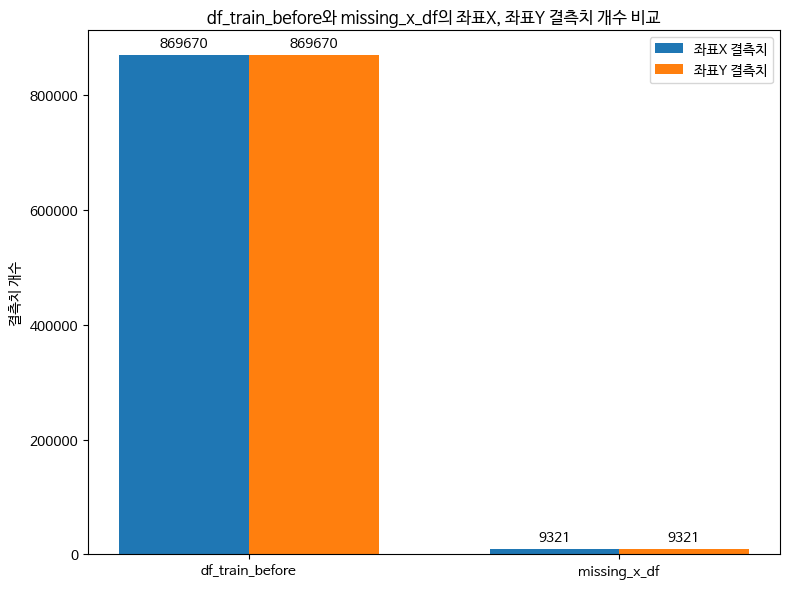

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

#한글 폰트 설정 
fe = fm.FontEntry(
    fname=r'C:\\Windows\\Fonts\\NanumBarunGothic.ttf',
    name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumBarunGothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False        # 마이너스 깨짐 방지



# 각 데이터프레임의 결측치 개수 계산
missing_before_x = df_train_before['좌표X'].isna().sum()
missing_before_y = df_train_before['좌표Y'].isna().sum()
missing_xdf_x = missing_x_df['좌표X'].isna().sum()
missing_xdf_y = missing_x_df['좌표Y'].isna().sum()

labels = ['df_train_before', 'missing_x_df']
missing_x = [missing_before_x, missing_xdf_x]
missing_y = [missing_before_y, missing_xdf_y]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, missing_x, width, label='좌표X 결측치')
rects2 = ax.bar(x + width/2, missing_y, width, label='좌표Y 결측치')

ax.set_ylabel('결측치 개수')
ax.set_title('df_train_before와 missing_x_df의 좌표X, 좌표Y 결측치 개수 비교')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# 막대 위에 결측치 개수 표시
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

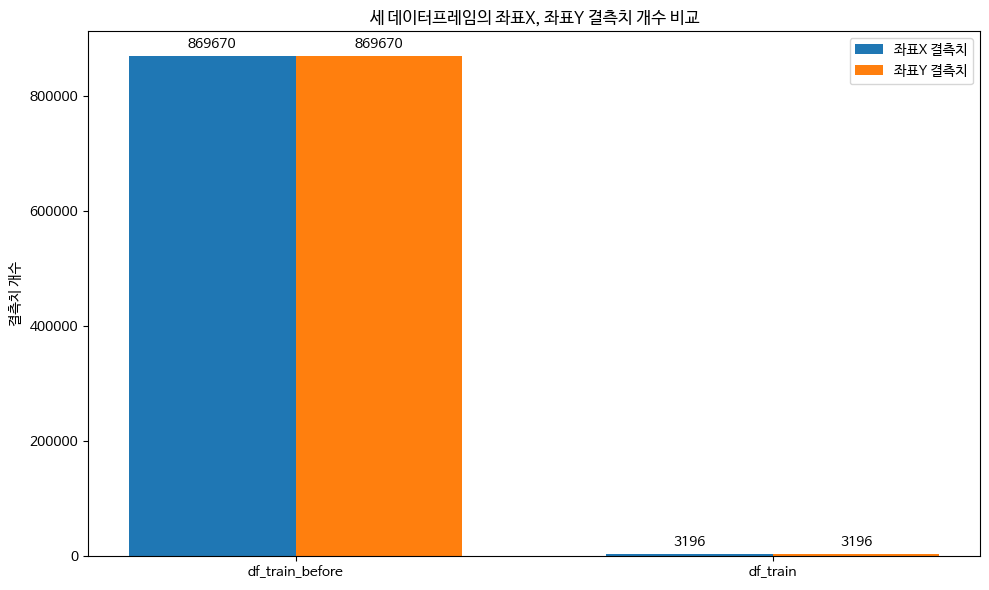

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

#한글 폰트 설정 
fe = fm.FontEntry(
    fname=r'C:\\Windows\\Fonts\\NanumBarunGothic.ttf',
    name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumBarunGothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False        # 마이너스 깨짐 방지


# 각 데이터프레임의 결측치 개수 계산
missing_before_x = df_train_before['좌표X'].isna().sum()
missing_before_y = df_train_before['좌표Y'].isna().sum()
missing_train_x = df_train['좌표X'].isna().sum()
missing_train_y = df_train['좌표Y'].isna().sum()

labels = ['df_train_before',  'df_train']
missing_x = [missing_before_x,  missing_train_x]
missing_y = [missing_before_y, missing_train_y]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, missing_x, width, label='좌표X 결측치')
rects2 = ax.bar(x + width/2, missing_y, width, label='좌표Y 결측치')

ax.set_ylabel('결측치 개수')
ax.set_title('두 데이터프레임의 좌표X, 좌표Y 결측치 개수 비교')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# 막대 위에 결측치 개수 표시
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 연습, 확인용 데이터 

In [ ]:
df_train[df_train['아파트명']=="더 제니스"]

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소


In [207]:
df_train[df_train['아파트명'].str.contains("서희", na=False)]

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소
18558,서울특별시,관악구,봉천동,서울특별시 관악구 봉천동,1729,1729,0.0,서희스타힐스,84.32,201801,...,189.0,임의,2022-07-11 09:31:23.0,Y,N,126.959534,37.488633,2022-07-10 11:47:09.0,53000,서울특별시 관악구 청림3길 10
18559,서울특별시,관악구,봉천동,서울특별시 관악구 봉천동,1729,1729,0.0,서희스타힐스,84.58,201802,...,189.0,임의,2022-07-11 09:31:23.0,Y,N,126.959534,37.488633,2022-07-10 11:47:09.0,53000,서울특별시 관악구 청림3길 10
18560,서울특별시,관악구,봉천동,서울특별시 관악구 봉천동,1729,1729,0.0,서희스타힐스,84.93,201802,...,189.0,임의,2022-07-11 09:31:23.0,Y,N,126.959534,37.488633,2022-07-10 11:47:09.0,49300,서울특별시 관악구 청림3길 10
18561,서울특별시,관악구,봉천동,서울특별시 관악구 봉천동,1729,1729,0.0,서희스타힐스,84.93,201803,...,189.0,임의,2022-07-11 09:31:23.0,Y,N,126.959534,37.488633,2022-07-10 11:47:09.0,52000,서울특별시 관악구 청림3길 10
18562,서울특별시,관악구,봉천동,서울특별시 관악구 봉천동,1729,1729,0.0,서희스타힐스,84.58,201804,...,189.0,임의,2022-07-11 09:31:23.0,Y,N,126.959534,37.488633,2022-07-10 11:47:09.0,52500,서울특별시 관악구 청림3길 10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891102,서울특별시,성북구,하월곡동,서울특별시 성북구 하월곡동,229,229,0.0,길음서희스타힐스,67.44,201303,...,325.0,의무,2011-06-24 00:00:00.0,Y,N,127.027329,37.605407,2013-03-07 09:46:45.0,31500,서울특별시 성북구 동소문로 284
891103,서울특별시,성북구,하월곡동,서울특별시 성북구 하월곡동,229,229,0.0,길음서희스타힐스,84.91,201304,...,325.0,의무,2011-06-24 00:00:00.0,Y,N,127.027329,37.605407,2013-03-07 09:46:45.0,39000,서울특별시 성북구 동소문로 284
891104,서울특별시,성북구,하월곡동,서울특별시 성북구 하월곡동,229,229,0.0,길음서희스타힐스,84.91,201304,...,325.0,의무,2011-06-24 00:00:00.0,Y,N,127.027329,37.605407,2013-03-07 09:46:45.0,33596,서울특별시 성북구 동소문로 284
891105,서울특별시,성북구,하월곡동,서울특별시 성북구 하월곡동,229,229,0.0,길음서희스타힐스,84.91,201306,...,325.0,의무,2011-06-24 00:00:00.0,Y,N,127.027329,37.605407,2013-03-07 09:46:45.0,39000,서울특별시 성북구 동소문로 284


In [ ]:
df_train[df_train['k-건설사(시공사)'].str.contains("신동아", na=False)]['k-건설사(시공사)'].unique()

array(['신동아', '신동아건설', '신동아건설(주)', '신동아 건설(주)'], dtype=object)

In [133]:
len(df_train)

1118822

In [ ]:
df_train[df_train['아파트명'].str.contains("상지리츠빌", na=False)]['k-건설사(시공사)'].unique()

array([nan], dtype=object)

In [ ]:

df_train[df_train['k-건설사(시공사)'].str.contains("두산중공업", na=False)]['아파트명'].unique()

array(['DMC두산위브', '트리마제', '청계천두산위브더제니스'], dtype=object)

In [ ]:
df_train[df_train['아파트명'].str.contains("써밋", na=False)]

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소
59075,서울특별시,서초구,서초동,서울특별시 서초구 서초동,1311-10,1311,10.0,서초푸르지오써밋,84.9500,201710,...,1284.0,의무,2018-10-11 17:11:37.0,Y,N,127.021203,37.501586,2017-07-14 05:20:39.0,153000,서울특별시 서초구 서운로 201
59076,서울특별시,서초구,서초동,서울특별시 서초구 서초동,1311-10,1311,10.0,서초푸르지오써밋,84.9300,201711,...,1284.0,의무,2018-10-11 17:11:37.0,Y,N,127.021203,37.501586,2017-07-14 05:20:39.0,156000,서울특별시 서초구 서운로 212
59077,서울특별시,서초구,서초동,서울특별시 서초구 서초동,1311-10,1311,10.0,서초푸르지오써밋,84.9500,201711,...,1284.0,의무,2018-10-11 17:11:37.0,Y,N,127.021203,37.501586,2017-07-14 05:20:39.0,159000,서울특별시 서초구 서운로 201
59078,서울특별시,서초구,서초동,서울특별시 서초구 서초동,1311-10,1311,10.0,서초푸르지오써밋,84.9500,201711,...,1284.0,의무,2018-10-11 17:11:37.0,Y,N,127.021203,37.501586,2017-07-14 05:20:39.0,162000,서울특별시 서초구 서운로 201
59079,서울특별시,서초구,서초동,서울특별시 서초구 서초동,1311-10,1311,10.0,서초푸르지오써밋,59.9200,201711,...,1284.0,의무,2018-10-11 17:11:37.0,Y,N,127.021203,37.501586,2017-07-14 05:20:39.0,132000,서울특별시 서초구 서운로 201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
816265,서울특별시,서초구,우면동,서울특별시 서초구 우면동,753,753,0.0,서초호반써밋,118.0151,201408,...,1102.0,의무,2014-10-23 08:55:10.0,Y,N,127.013285,37.456476,2014-10-22 16:09:08.0,80538,서울특별시 서초구 양재대로2길 109
816266,서울특별시,서초구,우면동,서울특별시 서초구 우면동,753,753,0.0,서초호반써밋,101.0482,201408,...,1102.0,의무,2014-10-23 08:55:10.0,Y,N,127.013285,37.456476,2014-10-22 16:09:08.0,81000,서울특별시 서초구 양재대로2길 109
816267,서울특별시,서초구,우면동,서울특별시 서초구 우면동,753,753,0.0,서초호반써밋,101.0109,201409,...,1102.0,의무,2014-10-23 08:55:10.0,Y,N,127.013285,37.456476,2014-10-22 16:09:08.0,78000,서울특별시 서초구 양재대로2길 109
909338,서울특별시,강남구,대치동,서울특별시 강남구 대치동,915-13,915,13.0,스카이써밋,120.0000,201105,...,NaN,NaN,NaN,NaN,NaN,127.058316,37.501139,NaN,30000,서울특별시 강남구 삼성로67길 14


In [ ]:
df_train.columns

Index(['시', '구', '동', '시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월',
       '계약일', '층', '건축년도', '도로명', '해제사유발생일', '등기신청일자', '거래유형', '중개사소재지',
       'k-단지분류(아파트,주상복합등등)', 'k-전화번호', 'k-팩스번호', '단지소개기존clob', 'k-세대타입(분양형태)',
       'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수', 'k-건설사(시공사)',
       'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적', 'k-관리비부과면적',
       'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)', 'k-85㎡~135㎡이하',
       'k-135㎡초과', 'k-홈페이지', 'k-등록일자', 'k-수정일자', '고용보험관리번호', '경비비관리형태',
       '세대전기계약방법', '청소비관리형태', '건축면적', '주차대수', '기타/의무/임대/임의=1/2/3/4', '단지승인일',
       '사용허가여부', '관리비 업로드', '좌표X', '좌표Y', '단지신청일', 'target', '도로명주소'],
      dtype='object')

In [ ]:
missing_coords_df[missing_coords_df['아파트명']=="마곡보타닉경남아너스빌"]

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target,도로명주소,지번주소
15146,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,84.9941,201710,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,52000,서울특별시 강서구 양천로26길 38,
15147,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,84.9941,201712,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,57000,서울특별시 강서구 양천로26길 38,
15148,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,84.9941,201712,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,52000,서울특별시 강서구 양천로26길 38,
15149,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,59.7672,201802,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,46000,서울특별시 강서구 양천로26길 38,
15150,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,59.7672,201803,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,47700,서울특별시 강서구 양천로26길 38,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975203,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,59.7672,201003,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,31000,서울특별시 강서구 양천로26길 38,
975204,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,59.7672,201003,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,30700,서울특별시 강서구 양천로26길 38,
975205,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,59.7672,201004,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,32000,서울특별시 강서구 양천로26길 38,
1016162,서울특별시,강서구,방화동,서울특별시 강서구 방화동,883,883,0.0,마곡보타닉경남아너스빌,84.9941,200802,...,NaN,NaN,NaN,NaN,126.818346550004,37.5722241634187,NaN,43000,서울특별시 강서구 양천로26길 38,


In [ ]:
df_add[df_add['아파트명']=="마곡보타닉경남아너스빌"]

,시군구,번지,아파트명,좌표X,좌표Y,elementary,elementary_dist,middle,middle_dist,high,high_dist,bus_station,bus_dist,subway_station,subway_dist,bus_walk,subway_walk,elementary_walk,middle_walk,high_walk


In [ ]:
df_test[df_test['아파트명']=="개나리4"]

,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,계약일,층,건축년도,...,청소비관리형태,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일
0,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,202307,26,5,1987,...,직영,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0


In [ ]:
df_train.columns

Index(['시군구', '번지', '본번', '부번', '아파트명', '전용면적(㎡)', '계약년월', '계약일', '층', '건축년도',
       '도로명', '해제사유발생일', '등기신청일자', '거래유형', 'k-단지분류(아파트,주상복합등등)',
       'k-세대타입(분양형태)', 'k-관리방식', 'k-복도유형', 'k-난방방식', 'k-전체동수', 'k-전체세대수',
       'k-건설사(시공사)', 'k-시행사', 'k-사용검사일-사용승인일', 'k-연면적', 'k-주거전용면적',
       'k-관리비부과면적', 'k-전용면적별세대현황(60㎡이하)', 'k-전용면적별세대현황(60㎡~85㎡이하)',
       'k-85㎡~135㎡이하', 'k-135㎡초과', 'k-등록일자', 'k-수정일자', '경비비관리형태', '세대전기계약방법',
       '청소비관리형태', '건축면적', '주차대수', '단지승인일', '사용허가여부', '좌표X', '좌표Y', '단지신청일',
       'target'],
      dtype='object')